# Names
1. Salma ALKHALILY
2. Nagham ABUWARDA
3. Ran LU
4. Ali Alhaj

# Scientific Article Information Retrieval Challenge

This notebook guides you through the challenge step by step:

1. **Section 1 — Setup & Data Exploration**: install packages, load data, understand its structure and statistics.
2. **Section 2 — Helper Functions**: reusable utilities for data loading, chunk extraction, metrics, and evaluation.
3. **Section 3 — TF-IDF Baseline**: sparse retrieval over title + abstract.
4. **Section 4 — Dense Retrieval Baseline**: retrieval using pre-computed dense embeddings.

---

## Task Description

Given a **query** (a scientific paper), retrieve the most relevant documents from a shared **corpus** of 20,000 papers.  
Relevance is defined by **citation**: the gold documents are papers that the query paper cites.

**Submission format**: a JSON file `{query_id: [doc_id_1, ..., doc_id_100]}` — exactly 100 ranked document IDs per query.

**Evaluation**: Recall@10, Recall@100, Precision@10, MRR@10, NDCG@10, NDCG@100, MAP — computed on 100 public queries.

## Environment Setup

Run the following commands **once** from the `ir_challenge/` root folder to create a virtual environment and install all dependencies:

```bash
# Create the virtual environment with Python 3.10
python3.10 -m venv .venv

# Activate it
source .venv/bin/activate          # macOS / Linux
# .venv\Scripts\activate           # Windows

# Install dependencies
pip install -r requirements.txt
```

### Registering the kernel in Jupyter (if not detected automatically)

If Jupyter does not show the environment as a kernel option, run these two extra commands while the venv is activated:

```bash
pip install ipykernel
python -m ipykernel install --user --name ir_challenge --display-name "IR Challenge"
```

Then restart Jupyter and select **IR Challenge** from the kernel menu (`Kernel → Change Kernel`).

---

### VS Code: kernel disappears after trusting the workspace

This is a known VS Code bug — trusting the workspace triggers a re-scan that can drop `.venv` from the kernel list. Try the fixes below in order:

**Fix 1 — Register the kernel explicitly (most reliable)**

Run the two `ipykernel` commands above. This registers it as a Jupyter kernel (not just a Python environment), so it persists across trust changes. Look for it under **Select Another Kernel → Jupyter Kernel...** instead of *Python Environments*.

**Fix 2 — Set the interpreter path manually**

1. Open Command Palette (`Cmd+Shift+P` / `Ctrl+Shift+P`)
2. Type `Python: Select Interpreter`
3. Choose **Enter interpreter path...**
4. Paste: `.venv/bin/python`

Then select the kernel in the notebook — it should now stick.

**Fix 3 — Add interpreter path to VS Code workspace settings**

Open Command Palette → **Preferences: Open Workspace Settings (JSON)** and add:

```json
{
    "python.defaultInterpreterPath": "${workspaceFolder}/.venv/bin/python"
}
```

---
## Folder Structure

```
ir_challenge/
├── data/
│   ├── queries.parquet          # 100 public queries (the papers you retrieve for)
│   ├── corpus.parquet           # 20,000 candidate documents to search over
│   ├── qrels.json               # ground-truth relevance: {query_id: [doc_id, ...]}
│   ├── sample_submission.json   # example of the required submission format
│   └── embeddings/
│       └── sentence-transformers_all-MiniLM-L6-v2/   # pre-computed embeddings
│           ├── query_embeddings.npy   # shape (100, 384)
│           ├── corpus_embeddings.npy  # shape (20000, 384)
│           ├── query_ids.json         # ordered list of query doc_ids
│           ├── corpus_ids.json        # ordered list of corpus doc_ids
│           └── model_info.txt         # model name, dim, normalisation flag
├── notebooks/
│   └── challenge.ipynb          # this notebook
├── scripts/
│   └── embed.py                 # helper to re-encode with any sentence-transformers model
├── submissions/                 # created automatically when you save results
└── requirements.txt
```

### Data files

| File | Rows | Key columns |
|------|------|-------------|
| `queries.parquet` | 100 | `doc_id`, `title`, `abstract`, `ta`, `full_text`, `chunk_meta`, `domain`, `year`, `n_relevant` |
| `corpus.parquet`  | 20,000 | same columns minus `n_relevant` |
| `qrels.json` | 100 queries | `{query_id: [gold_doc_id, ...]}` — a query may have multiple relevant documents |

`n_relevant` tells you how many gold documents for that query are present in the corpus.

### Pre-computed embeddings

The embeddings were produced by [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) encoding `title + " " + abstract` for every paper. They are **L2-normalised**, so cosine similarity reduces to a dot product.

### `scripts/embed.py` — re-encoding with a different model

If you want to experiment with a stronger encoder, run this from the `ir_challenge/` folder:

```bash
python scripts/embed.py --model BAAI/bge-small-en-v1.5
```

The script automatically creates a model-named subdirectory under `data/embeddings/` so different models never overwrite each other:

```
data/embeddings/
├── sentence-transformers_all-MiniLM-L6-v2/   ← pre-computed (shipped)
└── BAAI_bge-small-en-v1.5/                   ← your new model
```

To use a custom output path explicitly:

```bash
python scripts/embed.py --model BAAI/bge-small-en-v1.5 --output data/embeddings/my_model/
```

Full options: `python scripts/embed.py --help`

---
## Section 1 — Setup & Data Exploration

In [ ]:
!pip install -q pandas pyarrow scikit-learn numpy matplotlib seaborn tqdm

In [ ]:
import json
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')
# Paths — adjust if your layout differs
DATA_DIR = Path('/content/drive/My Drive/challenge/data')

# Verify files exist
for f in ["held_out_queries.parquet", "corpus.parquet", "qrels.json", "sample_submission.json"]:
    path = DATA_DIR / f
    status = "✓" if path.exists() else "✗ MISSING"
    print(f"  {status}  {path}")

Mounted at /content/drive
  ✓  /content/drive/My Drive/challenge/data/held_out_queries.parquet
  ✓  /content/drive/My Drive/challenge/data/corpus.parquet
  ✓  /content/drive/My Drive/challenge/data/qrels.json
  ✓  /content/drive/My Drive/challenge/data/sample_submission.json


In [ ]:
# Load data
queries = pd.read_parquet(DATA_DIR / "queries.parquet")
corpus  = pd.read_parquet(DATA_DIR / "corpus.parquet")
with open(DATA_DIR / "qrels.json") as f:
    qrels = json.load(f)

print(f"Queries : {len(queries):,} rows — columns: {queries.columns.tolist()}")
print(f"Corpus  : {len(corpus):,} rows  — columns: {corpus.columns.tolist()}")
print(f"Qrels   : {len(qrels):,} queries with gold annotations")

Queries : 100 rows — columns: ['doc_id', 'title', 'abstract', 'ta', 'full_text', 'chunk_meta', 'venue', 'domain', 'year', 'n_relevant']
Corpus  : 20,000 rows  — columns: ['doc_id', 'title', 'abstract', 'ta', 'full_text', 'chunk_meta', 'venue', 'domain', 'year']
Qrels   : 100 queries with gold annotations


In [ ]:
# Sample query — all available fields
q = queries.iloc[0]
print(f"doc_id     : {q['doc_id']}")
print(f"domain     : {q['domain']}")
print(f"year       : {q['year']}")
print(f"n_relevant : {q['n_relevant']}")
print(f"\nTitle      : {q['title'][:120]}")
print(f"\nAbstract   : {q['abstract'][:300]} ...")
print(f"\nFull-text length (chars) : {len(q['full_text']):,}")
print(f"Chunk meta entries       : {len(json.loads(q['chunk_meta']))}")

doc_id     : 5226ac1019c028800679a3c1badccfbde9ceecef
domain     : Biology
year       : 2021
n_relevant : 6

Title      : Ecotypic Morphological and Physio-Biochemical Responses of Two Differentially Adapted Forage Grasses, Cenchrus ciliaris 

Abstract   : : Crop performance and yield are the results of genotypic expression as modulated by continuous interaction with the environment. Among the environmental aspects, drought and salinity are the most important factors, which limit the forages, including grasses, on a global basis. Grass species have th ...

Full-text length (chars) : 30,698
Chunk meta entries       : 27


In [ ]:
# Show a query and its gold documents side by side
qid = queries.iloc[0]["doc_id"]
gold_ids = qrels.get(qid, [])
gold_docs = corpus[corpus["doc_id"].isin(gold_ids)]

print("=" * 80)
print("QUERY")
print("=" * 80)
print(queries.iloc[0]["title"])
print(f"\n{queries.iloc[0]['abstract'][:300]}...")

print(f"\n=== GOLD DOCUMENTS ({len(gold_ids)} total) ===")
for _, row in gold_docs.head(3).iterrows():
    print(f"\n  [{row['doc_id']}]")
    print(f"  {row['title']}")
    print(f"  {row['abstract'][:200]}...")

QUERY
Ecotypic Morphological and Physio-Biochemical Responses of Two Differentially Adapted Forage Grasses, Cenchrus ciliaris L. and Cyperus arenarius Retz. to Drought Stress

: Crop performance and yield are the results of genotypic expression as modulated by continuous interaction with the environment. Among the environmental aspects, drought and salinity are the most important factors, which limit the forages, including grasses, on a global basis. Grass species have th...

=== GOLD DOCUMENTS (6 total) ===

  [bbccde934828e0f9f8cc32df0e557b83354e04bf]
  Foliar Spraying with Potassium Bicarbonate Reduces the Negative Impact of Drought Stress on Sweet Basil (Ocimum basilicum L.)
  In recent years, special attention has been paid to climate change assessment and research into our changing environment. The greatest economic losses worldwide are due to the negative effects of drou...

  [bbe69debbe2417bd2b822bad3098b562d0d90c22]
  Jute: A Potential Candidate for Phytoremediation of Metals

In [ ]:
# ── TODO 1 ───────────────────────────────────────────────────────────────────
# Pick a query from a domain of your choice and inspect it.
# Print its title and the titles of its gold documents.
# Do the gold documents share keywords or themes with the query?
#
# Hint: queries["domain"].unique() lists available domains.
#       Use qrels[qid] to get the gold doc IDs for a given query ID.
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE
cp_query = queries[queries["domain"] == "Computer Science"]

# Select the first Computer Science query
selected_query = cp_query.iloc[0]
qid = selected_query["doc_id"]

print(f"Selected Query (CS): {selected_query['title']}")

gold_doc_ids = qrels.get(qid, [])
if gold_doc_ids:
    gold_docs = corpus[corpus["doc_id"].isin(gold_doc_ids)]
    print(f"\nGold Documents for Query '{selected_query['title']}' ({len(gold_doc_ids)} total):")
    for _, row in gold_docs.iterrows():
        print(f"  - {row['title']}")
else:
    print(f"\nNo gold documents found for query '{selected_query['title']}'.")

# Based on the output, you can manually inspect for shared keywords or themes.


Selected Query (CS): Parametric Acoustic Array and Its Application in Underwater Acoustic Engineering

Gold Documents for Query 'Parametric Acoustic Array and Its Application in Underwater Acoustic Engineering' (4 total):
  - Experimental Study of a Broadband Parametric Acoustic Array for Sub-Bottom Profiling in Shallow Water
  - Comparative Experimental Investigation on Optimal Parametric Array Types
  - Design of a Broadband Electrical Impedance Matching Network for Piezoelectric Ultrasound Transducers Based on a Genetic Algorithm
  - Effects of using inclined parametric echosounding on sub-bottom acoustic imaging and advances in buried object detection


In [ ]:
# ── About this dataset ────────────────────────────────────────────────────
#
# This challenge dataset is a small, curated subset of a larger citation-based
# evaluation benchmark we built from Semantic Scholar (covering 63K papers across
# 19 scientific domains). Queries are citing papers; gold documents are the papers
# they cite. The full evaluation set has ~10K queries — here you work with 100.
#
# Data creation pipeline (briefly):
#   1. Papers were filtered by venue, abstract presence, and minimum text length.
#   2. Citation pairs (A cites B) were extracted and bidirectionally deduplicated.
#   3. A held-out evaluation set was stratified-sampled across all 19 domains,
#      ensuring zero paper overlap with the training split.
#   4. 100 queries were sampled from this eval set (proportional domain coverage),
#      and a 20,000-document corpus was built by combining their gold citations
#      with randomly sampled negatives from the same paper pool.
#
# Each paper exposes: title, abstract (TA), full_text, and chunk_meta.
# chunk_meta encodes pre-computed section boundaries for chunk-level retrieval.
# ─────────────────────────────────────────────────────────────────────────
print("See comments above for the data creation pipeline summary.")

See comments above for the data creation pipeline summary.


### 1.1 — Domain & Year Distributions

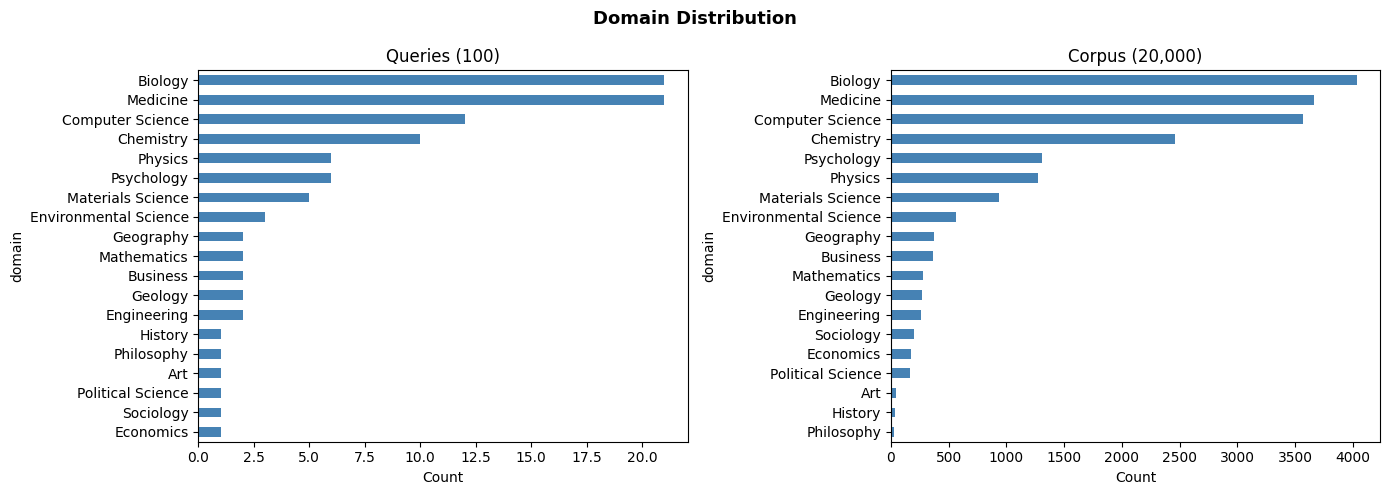

In [ ]:
# Domain distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [
    (axes[0], queries, "Queries (100)"),
    (axes[1], corpus,  "Corpus (20,000)"),
]:
    counts = df["domain"].value_counts()
    counts.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.invert_yaxis()
plt.suptitle("Domain Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

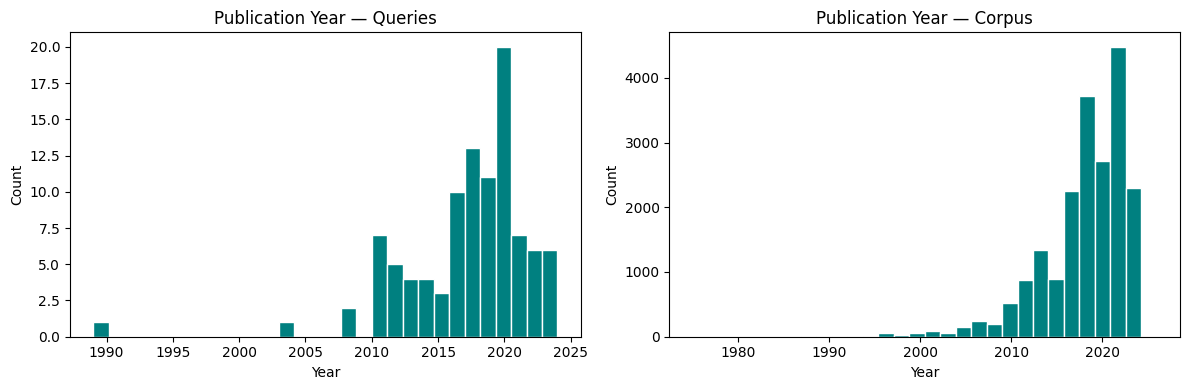

In [ ]:
# Year distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in [
    (axes[0], queries, "Queries"),
    (axes[1], corpus,  "Corpus"),
]:
    years = df["year"].replace(0, np.nan).dropna()
    ax.hist(years, bins=30, color="teal", edgecolor="white")
    ax.set_title(f"Publication Year — {title}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 1.2 — Venue Statistics


Unique venues — corpus: 2,972   queries: 73


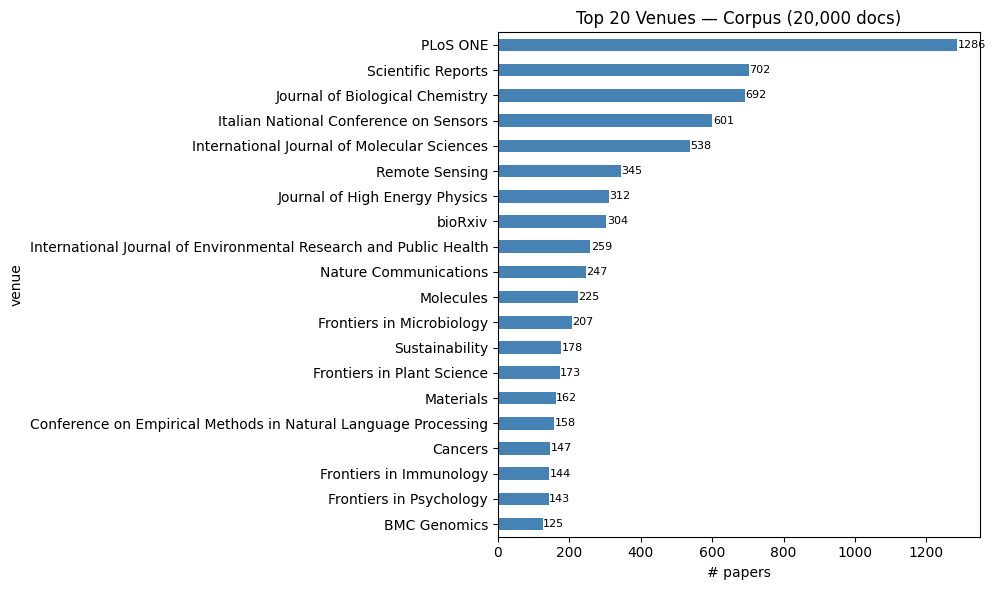


Top 3 venues per domain (5 largest domains):

  Biology:
     442  PLoS ONE
     309  Journal of Biological Chemistry
     169  International Journal of Molecular Sciences

  Medicine:
     241  PLoS ONE
     168  International Journal of Molecular Sciences
     108  Scientific Reports

  Computer Science:
     422  Italian National Conference on Sensors
     234  Remote Sensing
     157  Conference on Empirical Methods in Natural Language Processing

  Chemistry:
     299  Journal of Biological Chemistry
     155  PLoS ONE
     143  International Journal of Molecular Sciences

  Psychology:
     113  PLoS ONE
     100  Frontiers in Psychology
      68  International Journal of Environmental Research and Public Health


In [ ]:
# Venue statistics
n_unique_corpus  = corpus["venue"].replace("", pd.NA).dropna().nunique()
n_unique_queries = queries["venue"].replace("", pd.NA).dropna().nunique()
print(f"Unique venues — corpus: {n_unique_corpus:,}   queries: {n_unique_queries:,}")

# Top 20 venues in corpus
top_venues = (
    corpus["venue"]
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_venues.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 Venues — Corpus (20,000 docs)")
ax.set_xlabel("# papers")
ax.invert_yaxis()
for i, v in enumerate(top_venues):
    ax.text(v + 1, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.show()

# Top venues per domain (top 3 venues for the 5 largest domains)
print("\nTop 3 venues per domain (5 largest domains):")
top5_domains = corpus["domain"].value_counts().head(5).index
for domain in top5_domains:
    top3 = (
        corpus[corpus["domain"] == domain]["venue"]
        .replace("", pd.NA).dropna()
        .value_counts().head(3)
    )
    print(f"\n  {domain}:")
    for venue, count in top3.items():
        print(f"    {count:>4}  {venue}")

### 1.3 — Citation & Relevance Stats


Gold docs per query:
  mean=7.36  median=3  min=2  max=71
  Queries with 1 gold  : 0
  Queries with 2–4     : 66
  Queries with 5+      : 34


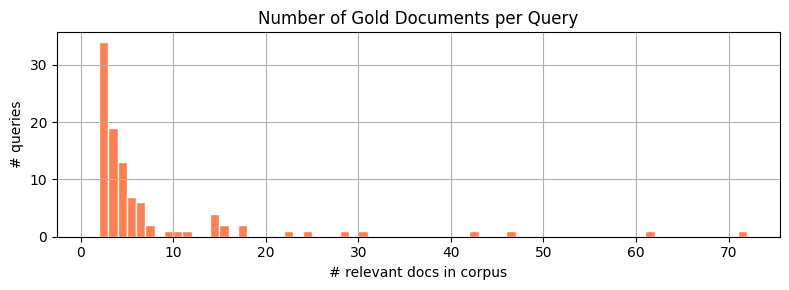

In [ ]:
# Relevance distribution (how many gold docs per query?)
n_relevant = queries["n_relevant"]
print("Gold docs per query:")
print(f"  mean={n_relevant.mean():.2f}  median={n_relevant.median():.0f}  "
      f"min={n_relevant.min()}  max={n_relevant.max()}")
print(f"  Queries with 1 gold  : {(n_relevant == 1).sum()}")
print(f"  Queries with 2–4     : {((n_relevant >= 2) & (n_relevant <= 4)).sum()}")
print(f"  Queries with 5+      : {(n_relevant >= 5).sum()}")

fig, ax = plt.subplots(figsize=(8, 3))
n_relevant.hist(bins=range(1, n_relevant.max() + 2), ax=ax, color="coral", edgecolor="white")
ax.set_title("Number of Gold Documents per Query")
ax.set_xlabel("# relevant docs in corpus")
ax.set_ylabel("# queries")
plt.tight_layout()
plt.show()

In [ ]:
# Verify all gold docs are present in corpus
corpus_id_set = set(corpus["doc_id"])
coverage = [
    sum(1 for d in docs if d in corpus_id_set) / len(docs)
    for docs in qrels.values() if docs
]
print(f"Average gold coverage in corpus : {np.mean(coverage):.1%}")
print(f"Queries with full coverage      : {sum(1 for c in coverage if c == 1.0)} / {len(coverage)}")

Average gold coverage in corpus : 100.0%
Queries with full coverage      : 100 / 100


### 1.4 — Title + Abstract Length Distribution


Queries TA length (chars):  mean=1524  median=1459  p5=663  p95=2344  max=3248
Corpus TA length (chars):  mean=1663  median=1592  p5=826  p95=2614  max=16514


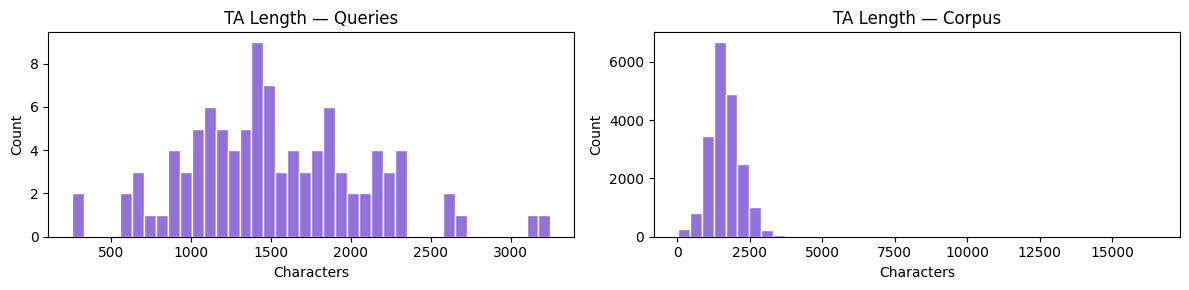

In [ ]:
# TA length stats
for df, label in [(queries, "Queries"), (corpus, "Corpus")]:
    ta_len = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.len()
    print(f"{label} TA length (chars):  mean={ta_len.mean():.0f}  "
          f"median={ta_len.median():.0f}  p5={ta_len.quantile(0.05):.0f}  "
          f"p95={ta_len.quantile(0.95):.0f}  max={ta_len.max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, df, label in [(axes[0], queries, "Queries"), (axes[1], corpus, "Corpus")]:
    ta_len = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.len()
    ax.hist(ta_len, bins=40, color="mediumpurple", edgecolor="white")
    ax.set_title(f"TA Length — {label}")
    ax.set_xlabel("Characters")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 1.4 — Full-Text & Chunk Statistics

Each paper includes a `full_text` field (body text with paragraphs separated by `\n\n`) and a `chunk_meta` field encoding pre-computed section boundaries.  
Each entry has a `type` (`"ta"` or `"body"`) and a `char_start` offset into `full_text`.  
The `ta` entry additionally has `char_end`, so it can be sliced directly: `full_text[char_start:char_end]`.  
Body entries only have `char_start` — a section runs from its `char_start` to the next entry's `char_start` (or the end of `full_text` for the last section). The `get_chunks()` helper in Section 2 handles this automatically.

In [ ]:
# Parse chunk_meta for all corpus docs
def parse_chunk_meta(cm_str):
    return json.loads(cm_str) if isinstance(cm_str, str) and cm_str else []

corpus_chunks = corpus["chunk_meta"].apply(parse_chunk_meta)
query_chunks  = queries["chunk_meta"].apply(parse_chunk_meta)

# Number of body chunks per paper (exclude the TA entry)
def n_body_chunks(meta):
    return sum(1 for e in meta if e.get("type") == "body")

corpus_n_body = corpus_chunks.apply(n_body_chunks)
query_n_body  = query_chunks.apply(n_body_chunks)

for label, s in [("Corpus", corpus_n_body), ("Queries", query_n_body)]:
    print(f"{label} body chunks/paper:  mean={s.mean():.1f}  "
          f"median={s.median():.0f}  min={s.min()}  max={s.max()}  "
          f"p5={s.quantile(0.05):.0f}  p95={s.quantile(0.95):.0f}")

Corpus body chunks/paper:  mean=10.8  median=9  min=2  max=156  p5=2  p95=24
Queries body chunks/paper:  mean=10.1  median=8  min=2  max=42  p5=2  p95=21


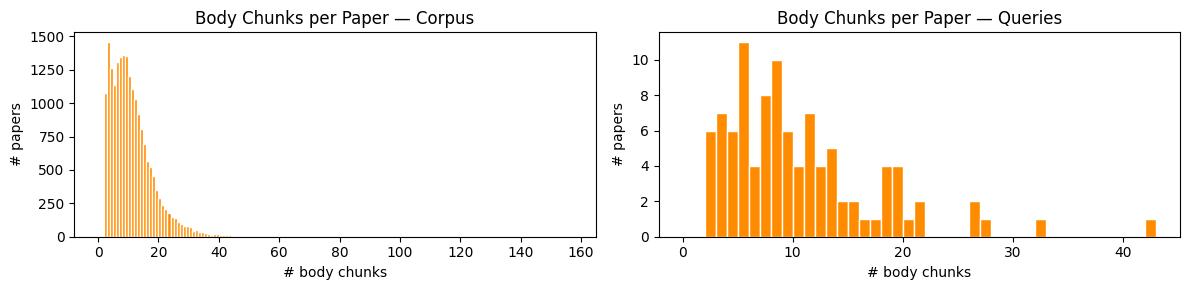

In [ ]:
# Distribution of body chunk counts
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, s, label in [
    (axes[0], corpus_n_body, "Corpus"),
    (axes[1], query_n_body,  "Queries"),
]:
    ax.hist(s, bins=range(0, s.max() + 2), color="darkorange", edgecolor="white")
    ax.set_title(f"Body Chunks per Paper — {label}")
    ax.set_xlabel("# body chunks")
    ax.set_ylabel("# papers")
plt.tight_layout()
plt.show()

In [ ]:
# Inspect chunks for a single paper
sample_row = corpus.iloc[0]
meta = parse_chunk_meta(sample_row["chunk_meta"])
full_text = sample_row["full_text"]

print(f"Paper: {sample_row['doc_id']}")
print(f"Title: {sample_row['title'][:80]}")
print(f"Total chunk entries: {len(meta)}  (1 TA + {len(meta)-1} body)\n")

for i, entry in enumerate(meta[:4]):   # show first 4 entries
    char_start = entry["char_start"]
    char_end   = entry.get("char_end") or (
        meta[i + 1]["char_start"] if i + 1 < len(meta) else len(full_text)
    )
    text = full_text[char_start:char_end].strip()
    print(f"[{i}] {entry['type'].upper()} chunk  chars {char_start}–{char_end}  ({char_end - char_start} chars)")
    print(f"    {text[:300]} ...")
    print()

Paper: f1c5e98774c4c7eb68496979cab2e57b8dcb2026
Title: Model-Observer Similarity, Error Modeling and Social Learning in Rhesus Macaques
Total chunk entries: 16  (1 TA + 15 body)

[0] TA chunk  chars 0–2033  (2033 chars)
    Model-Observer Similarity, Error Modeling and Social Learning in Rhesus Macaques

Monkeys readily learn to discriminate between rewarded and unrewarded items or actions by observing their conspecifics. However, they do not systematically learn from humans. Understanding what makes human-to-monkey tr ...

[1] BODY chunk  chars 8726–8876  (150 chars)
    Materials and Methods
The paragraphs below provide a brief description of the subjects and procedures. A more detailed account is available in [10]. ...

[2] BODY chunk  chars 8876–8946  (70 chars)
    Ethics
The study was carried out in strict accordance with Directive ...

[3] BODY chunk  chars 8946–9613  (667 chars)
    Enrichment
The animals housing quarters matched or exceeded the minimal surface, height, and vol

Corpus full_text length (chars): mean=39700  median=35956  p5=16622  p95=74762


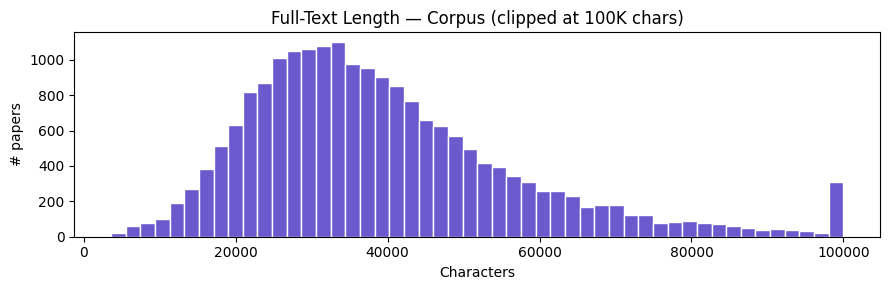

In [ ]:
# Full-text length distribution (corpus)
ft_len = corpus["full_text"].str.len()
print(f"Corpus full_text length (chars): mean={ft_len.mean():.0f}  "
      f"median={ft_len.median():.0f}  p5={ft_len.quantile(0.05):.0f}  "
      f"p95={ft_len.quantile(0.95):.0f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(ft_len.clip(upper=100_000), bins=50, color="slateblue", edgecolor="white")
ax.set_title("Full-Text Length — Corpus (clipped at 100K chars)")
ax.set_xlabel("Characters")
ax.set_ylabel("# papers")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5201/3589960137.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_domain, labels=domain_order, patch_artist=True,


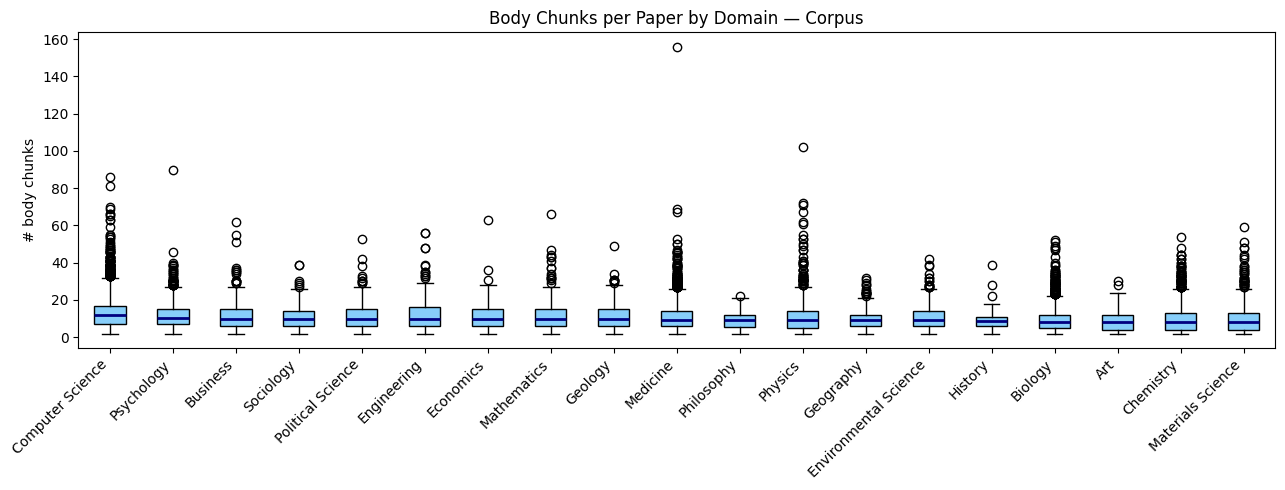


Domain                        Papers  Median chunks  Median section (chars)
---------------------------------------------------------------------------
Computer Science                3571             12                    1642
Psychology                      1306             10                    1583
Business                         363             10                    1782
Sociology                        196             10                    2212
Political Science                168             10                    1889
Engineering                      264             10                    1843
Economics                        173             10                    1967
Mathematics                      277             10                    1607
Geology                          273             10                    2086
Medicine                        3662              9                    1571
Philosophy                        27              9                    2910
Physics    

In [ ]:
# Body chunks per paper broken down by domain
corpus["n_body_chunks"] = corpus["chunk_meta"].apply(
    lambda cm: sum(1 for e in json.loads(cm) if e.get("type") == "body")
)

domain_order = corpus.groupby("domain")["n_body_chunks"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
data_by_domain = [corpus[corpus["domain"] == d]["n_body_chunks"].values for d in domain_order]
ax.boxplot(data_by_domain, labels=domain_order, patch_artist=True,
           boxprops=dict(facecolor="lightskyblue"), medianprops=dict(color="navy", linewidth=2))
ax.set_title("Body Chunks per Paper by Domain — Corpus")
ax.set_ylabel("# body chunks")
ax.set_xticklabels(domain_order, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Median body chunks and section length per domain
print(f"\n{'Domain':<28}  {'Papers':>6}  {'Median chunks':>13}  {'Median section (chars)':>22}")
print("-" * 75)
for domain in domain_order:
    sub = corpus[corpus["domain"] == domain]
    med_chunks = sub["n_body_chunks"].median()
    section_lens = []
    for row in sub.itertuples():
        meta = json.loads(row.chunk_meta)
        body = [e for e in meta if e.get("type") == "body"]
        for j, e in enumerate(body):
            end = body[j + 1]["char_start"] if j + 1 < len(body) else len(row.full_text)
            section_lens.append(end - e["char_start"])
    med_sec = int(np.median(section_lens)) if section_lens else 0
    print(f"{domain:<28}  {len(sub):>6}  {med_chunks:>13.0f}  {med_sec:>22}")

---
## Section 2 — Helper Functions

All reusable utilities are defined here. **Run this cell before any retrieval section.**

In [ ]:
# ════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS — run this block before any retrieval
# ════════════════════════════════════════════════════════════

import json, math, os
from pathlib import Path
import numpy as np
import pandas as pd

# ── Data loaders ────────────────────────────────────────────

def load_queries(path) -> pd.DataFrame:
    """Load queries.parquet → DataFrame with doc_id, title, abstract, ta, full_text, chunk_meta, domain, year, n_relevant."""
    return pd.read_parquet(path)


def load_corpus(path) -> pd.DataFrame:
    """Load corpus.parquet → DataFrame with doc_id, title, abstract, ta, full_text, chunk_meta, domain, year."""
    return pd.read_parquet(path)


def load_qrels(path) -> dict:
    """Load qrels.json → {query_id: [doc_id, ...]}"""
    with open(path) as f:
        return json.load(f)


def load_embeddings(emb_path, ids_path):
    """
    Load pre-computed embeddings and their corresponding IDs.
    Returns (embeddings: np.ndarray float32, ids: list).
    """
    embeddings = np.load(emb_path).astype(np.float32)
    with open(ids_path) as f:
        ids = json.load(f)
    assert len(embeddings) == len(ids), "Embedding count mismatch"
    return embeddings, ids


# ── Text formatting ──────────────────────────────────────────

def format_text(row) -> str:
    """Return title + abstract as a single string for retrieval."""
    title    = str(row.get("title", "") or "").strip()
    abstract = str(row.get("abstract", "") or "").strip()
    if title and abstract:
        return title + " " + abstract
    return title or abstract


# ── Chunk extraction ─────────────────────────────────────────

def get_chunks(full_text: str, chunk_meta_json) -> list:
    """
    Extract all text sections from a paper using pre-computed chunk metadata.

    Each chunk entry has char_start and (for body chunks) the end is inferred
    as the start of the next section, or the end of full_text for the last one.

    Args:
        full_text:       raw paper text (paragraphs separated by \\n\\n)
        chunk_meta_json: JSON string or list of chunk entries from chunk_meta

    Returns:
        list of dicts: [{"type": "ta"|"body", "text": str,
                         "char_start": int, "char_end": int}]
    """
    meta = json.loads(chunk_meta_json) if isinstance(chunk_meta_json, str) else chunk_meta_json
    chunks = []
    for i, entry in enumerate(meta):
        char_start = entry["char_start"]
        if entry["type"] == "ta":
            char_end = entry["char_end"]
        else:
            # Body section spans from char_start to the next section's start (or end of text)
            char_end = meta[i + 1]["char_start"] if i + 1 < len(meta) else len(full_text)
        text = full_text[char_start:char_end].strip()
        chunks.append({"type": entry["type"], "text": text,
                       "char_start": char_start, "char_end": char_end})
    return chunks


def get_ta(row) -> str:
    """Return the pre-extracted title+abstract string from a paper row."""
    return str(row.get("ta", "") or "").strip()


def get_body_chunks(row, min_chars: int = 100) -> list:
    """
    Return all body section texts for a paper row, filtering out very short sections.

    Args:
        row:       a DataFrame row with full_text and chunk_meta columns
        min_chars: minimum character length to keep a section (default 100)
    """
    chunks = get_chunks(row["full_text"], row["chunk_meta"])
    return [c["text"] for c in chunks
            if c["type"] == "body" and len(c["text"]) >= min_chars]


# ── Metric functions (per-query) ─────────────────────────────

def recall_at_k(ranked: list, relevant: set, k: int) -> float:
    """Fraction of relevant docs found in the top-k results."""
    if not relevant:
        return 0.0
    hits = sum(1 for doc in ranked[:k] if doc in relevant)
    return hits / len(relevant)


def precision_at_k(ranked: list, relevant: set, k: int) -> float:
    """Fraction of top-k results that are relevant."""
    if k == 0:
        return 0.0
    hits = sum(1 for doc in ranked[:k] if doc in relevant)
    return hits / k


def mrr_at_k(ranked: list, relevant: set, k: int) -> float:
    """Reciprocal rank of the first relevant document in top-k."""
    for rank, doc in enumerate(ranked[:k], start=1):
        if doc in relevant:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(ranked: list, relevant: set, k: int) -> float:
    """Normalized Discounted Cumulative Gain at k."""
    dcg = sum(
        1.0 / math.log2(rank + 1)
        for rank, doc in enumerate(ranked[:k], start=1)
        if doc in relevant
    )
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(r + 1) for r in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0


def average_precision(ranked: list, relevant: set) -> float:
    """Average Precision (area under the precision-recall curve) for one query."""
    if not relevant:
        return 0.0
    hits, score = 0, 0.0
    for rank, doc in enumerate(ranked, start=1):
        if doc in relevant:
            hits += 1
            score += hits / rank
    return score / len(relevant)


# ── Aggregate evaluation ─────────────────────────────────────

def evaluate(
    submission: dict,
    qrels: dict,
    ks: list = None,
    query_domains: dict = None,
    verbose: bool = True,
) -> dict:
    """
    Evaluate a retrieval submission.

    Args:
        submission:    {query_id: [top-100 doc_ids]}
        qrels:         {query_id: [relevant doc_ids]}
        ks:            cut-off values, default [10, 100]
        query_domains: {query_id: domain} — enables per-domain breakdown
        verbose:       print formatted results table

    Returns:
        dict with 'overall' metrics and optional 'per_domain'
    """
    if ks is None:
        ks = [10, 100]

    per_query = {}
    for qid, rel_list in qrels.items():
        relevant = set(rel_list)
        ranked   = submission.get(qid, [])
        q = {}
        for k in ks:
            q[f"Recall@{k}"]    = recall_at_k(ranked, relevant, k)
            q[f"Precision@{k}"] = precision_at_k(ranked, relevant, k)
            q[f"MRR@{k}"]       = mrr_at_k(ranked, relevant, k)
            q[f"NDCG@{k}"]      = ndcg_at_k(ranked, relevant, k)
        q["AP"] = average_precision(ranked, relevant)
        per_query[qid] = q

    metric_keys = list(next(iter(per_query.values())).keys()) if per_query else []
    overall = {}
    for key in metric_keys:
        vals = [per_query[qid][key] for qid in per_query]
        overall[key] = float(np.mean(vals))
    overall["MAP"] = overall.pop("AP", 0.0)
    overall["num_queries"] = len(per_query)

    result = {"overall": overall, "per_query": per_query}

    if query_domains:
        per_domain = {}
        for domain in sorted(set(query_domains.values())):
            dqids = [q for q in per_query if query_domains.get(q) == domain]
            if not dqids:
                continue
            dm = {}
            for key in metric_keys:
                dm[key] = float(np.mean([per_query[q][key] for q in dqids]))
            dm["MAP"] = dm.pop("AP", 0.0)
            dm["num_queries"] = len(dqids)
            per_domain[domain] = dm
        result["per_domain"] = per_domain

    if verbose:
        _print_results(result, ks)

    return result


def _print_results(results: dict, ks: list):
    o = results["overall"]
    print("\n" + "=" * 68)
    print("OVERALL RESULTS")
    print("=" * 68)
    for label, keys in [
        ("Recall",    [f"Recall@{k}"    for k in ks]),
        ("Precision", [f"Precision@{k}" for k in ks]),
        ("MRR",       [f"MRR@{k}"       for k in ks]),
        ("NDCG",      [f"NDCG@{k}"      for k in ks]),
    ]:
        row = f"{label:<14}"
        for k, key in zip(ks, keys):
            row += f"  @{k:>3}: {o.get(key, 0):.4f}"
        print(row)
    print(f"{'MAP':<14}  {o.get('MAP', 0):.4f}")
    print(f"{'Queries':<14}  {int(o.get('num_queries', 0))}")

    if "per_domain" in results:
        print("\n" + "-" * 68)
        print("PER-DOMAIN  (first k only)")
        print("-" * 68)
        k = ks[0]
        print(f"  {'Domain':<28} R@{k:<3} P@{k:<3} MRR@{k:<3} NDCG@{k:<3}  MAP    n")
        for domain, dm in sorted(results["per_domain"].items()):
            print(
                f"  {domain:<28}"
                f" {dm.get(f'Recall@{k}', 0):.3f}"
                f" {dm.get(f'Precision@{k}', 0):.3f}"
                f" {dm.get(f'MRR@{k}', 0):.3f}  "
                f" {dm.get(f'NDCG@{k}', 0):.3f}"
                f"  {dm.get('MAP', 0):.3f}"
                f"  {int(dm.get('num_queries', 0))}"
            )
    print()


print("Helper functions loaded.")

Helper functions loaded.


---
## Section 3 — TF-IDF Baseline

A simple sparse retrieval baseline using TF-IDF cosine similarity over **title + abstract** only.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load data (re-load in case this section is run independently)
DATA_DIR = Path("/content/drive/My Drive/challenge/data") # Corrected path
queries = load_queries(DATA_DIR /"held_out_queries.parquet")
corpus  = load_corpus(DATA_DIR / "corpus.parquet")
qrels   = load_qrels(DATA_DIR / "qrels.json")

query_ids  = queries["doc_id"].tolist()
corpus_ids = corpus["doc_id"].tolist()

# Use title + abstract for retrieval (TA only)
query_texts  = [format_text(row) for _, row in queries.iterrows()]
corpus_texts = [format_text(row) for _, row in corpus.iterrows()]

print(f"Queries : {len(query_texts)}")
print(f"Corpus  : {len(corpus_texts)}")

Queries : 100
Corpus  : 20000


In [ ]:
# Build TF-IDF index on corpus TA
vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 1),
    stop_words="english",
)
corpus_matrix = vectorizer.fit_transform(corpus_texts)   # (20000, vocab)
query_matrix  = vectorizer.transform(query_texts)        # (100, vocab)
print(f"Corpus matrix : {corpus_matrix.shape}  vocab={corpus_matrix.shape[1]:,}")
print(f"Query  matrix : {query_matrix.shape}")

Corpus matrix : (20000, 44105)  vocab=44,105
Query  matrix : (100, 44105)


In [ ]:
# Retrieve top-100 per query
TOP_K = 100
sim_matrix = cosine_similarity(query_matrix, corpus_matrix)   # (100, 20000)

tfidf_submission = {}
for i, qid in enumerate(query_ids):
    top_indices = np.argsort(-sim_matrix[i])[:TOP_K]
    tfidf_submission[qid] = [corpus_ids[j] for j in top_indices]

print(f"Submission: {len(tfidf_submission)} queries × {TOP_K} results")

Submission: 100 queries × 100 results


In [ ]:
# Evaluate
query_domains = dict(zip(queries["doc_id"], queries["domain"]))
tfidf_results = evaluate(tfidf_submission, qrels, ks=[10, 100],
                         query_domains=query_domains, verbose=True)


OVERALL RESULTS
Recall          @ 10: 0.0000  @100: 0.0000
Precision       @ 10: 0.0000  @100: 0.0000
MRR             @ 10: 0.0000  @100: 0.0000
NDCG            @ 10: 0.0000  @100: 0.0000
MAP             0.0000
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (first k only)
--------------------------------------------------------------------
  Domain                       R@10  P@10  MRR@10  NDCG@10   MAP    n



In [ ]:
# ── TODO 2 ───────────────────────────────────────────────────────────────────
# Pick any query and inspect its top-5 TF-IDF results.
# For each retrieved document, print its title and whether it is a gold doc.
#
# Hint: tfidf_submission[qid] gives the ranked list of doc IDs for that query.
#       qrels[qid] gives the set of gold doc IDs.
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE

# Pick the first query ID
query_to_inspect_id = query_ids[0]

# Get the gold documents for this query
gold_docs_for_query = set(qrels.get(query_to_inspect_id, []))

print(f"Inspecting top-5 TF-IDF results for query: {queries[queries['doc_id'] == query_to_inspect_id]['title'].iloc[0]}\n")

# Get the top-5 retrieved document IDs for the selected query
top_5_retrieved_ids = tfidf_submission.get(query_to_inspect_id, [])[:5]

if not top_5_retrieved_ids:
    print("No TF-IDF results found for this query.")
else:
    for i, doc_id in enumerate(top_5_retrieved_ids):
        doc_title = corpus[corpus['doc_id'] == doc_id]['title'].iloc[0]
        is_gold = "(GOLD)" if doc_id in gold_docs_for_query else ""
        print(f"  {i+1}. {doc_title} {is_gold}")


Inspecting top-5 TF-IDF results for query: The de Almeida-Thouless Line in Hierarchical Quantum Spin Glasses

  1. Equilibrium dynamics of infinite-range quantum spin glasses in a field 
  2. Longitudinal and transversal resonant tunneling of interacting bosons in a two-dimensional Josephson junction 
  3. Field Angle Tuned Metamagnetism and Lifschitz Transitions in UPt3 
  4. Cavity QED quantum phase gates for a single longitudinal mode of the intracavity field 
  5. Field redefinitions in effective theories at higher orders 


In [ ]:
# Save submission
submissions_dir = DATA_DIR.parent / "submissions"
os.makedirs(submissions_dir, exist_ok=True)
with open(submissions_dir / "tfidf_baseline.json", "w") as f:
    json.dump(tfidf_submission, f)
print(f"Saved → {submissions_dir / "tfidf_baseline.json"}")

Saved → /content/drive/My Drive/challenge/submissions/tfidf_baseline.json


---
## Section 4 — Dense Retrieval Baseline

Dense retrieval using pre-computed embeddings from [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) (22M params).  
Texts were encoded as `title + " " + abstract`. Embeddings are L2-normalised → cosine similarity = dot product.  
To re-encode with a different model, run `scripts/embed.py --model <model-name>`.

In [ ]:
EMB_DIR = DATA_DIR / "embeddings" / "sentence-transformers_all-MiniLM-L6-v2"

for f in ["query_embeddings.npy", "corpus_embeddings.npy",
          "query_ids.json", "corpus_ids.json", "model_info.txt"]:
    path = EMB_DIR / f
    status = "✓" if path.exists() else "✗ MISSING"
    print(f"  {status}  {path}")

if (EMB_DIR / "model_info.txt").exists():
    print("\nModel info:")
    print((EMB_DIR / "model_info.txt").read_text())

  ✓  /content/drive/My Drive/challenge/data/embeddings/sentence-transformers_all-MiniLM-L6-v2/query_embeddings.npy
  ✓  /content/drive/My Drive/challenge/data/embeddings/sentence-transformers_all-MiniLM-L6-v2/corpus_embeddings.npy
  ✓  /content/drive/My Drive/challenge/data/embeddings/sentence-transformers_all-MiniLM-L6-v2/query_ids.json
  ✓  /content/drive/My Drive/challenge/data/embeddings/sentence-transformers_all-MiniLM-L6-v2/corpus_ids.json
  ✓  /content/drive/My Drive/challenge/data/embeddings/sentence-transformers_all-MiniLM-L6-v2/model_info.txt

Model info:
model: sentence-transformers/all-MiniLM-L6-v2
embedding_dim: 384
normalize_embeddings: True
text_format: title + ' ' + abstract



In [ ]:
# Load embeddings
query_embs, q_ids = load_embeddings(EMB_DIR / "query_embeddings.npy",
                                     EMB_DIR / "query_ids.json")
corpus_embs, c_ids = load_embeddings(EMB_DIR / "corpus_embeddings.npy",
                                      EMB_DIR / "corpus_ids.json")
print(f"Query  embeddings : {query_embs.shape}")
print(f"Corpus embeddings : {corpus_embs.shape}")

Query  embeddings : (100, 384)
Corpus embeddings : (20000, 384)


In [ ]:
# Dense retrieval
TOP_K = 100

# ── TODO 3 ───────────────────────────────────────────────────────────────────
# Compute the cosine similarity matrix between all queries and all corpus docs.
# The embeddings are already L2-normalised, so cosine similarity = dot product.
# sim_matrix should have shape (n_queries, n_corpus).
#
# Hint: use matrix multiplication between query_embs and corpus_embs.
# ─────────────────────────────────────────────────────────────────────────────

sim_matrix = query_embs @ corpus_embs.T

top_indices = np.argsort(-sim_matrix, axis=1)[:, :TOP_K]          # (100, 100)

dense_submission = {qid: [c_ids[j] for j in top_indices[i]]
                    for i, qid in enumerate(q_ids)}
print(f"Submission: {len(dense_submission)} queries × {TOP_K} results")

Submission: 100 queries × 100 results


In [ ]:
# Evaluate
dense_results = evaluate(dense_submission, qrels, ks=[10, 100],
                         query_domains=query_domains, verbose=True)


OVERALL RESULTS
Recall          @ 10: 0.4716  @100: 0.8104
Precision       @ 10: 0.2440  @100: 0.0587
MRR             @ 10: 0.6812  @100: 0.6834
NDCG            @ 10: 0.5073  @100: 0.5903
MAP             0.4080
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (first k only)
--------------------------------------------------------------------
  Domain                       R@10  P@10  MRR@10  NDCG@10   MAP    n



In [ ]:
# Summary comparison
comparison = []
for name, res in [("TF-IDF", tfidf_results), ("all-MiniLM-L6-v2", dense_results)]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items() if k != "num_queries"})
    comparison.append(row)
pd.DataFrame(comparison).set_index("Model")

,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
all-MiniLM-L6-v2,0.4716,0.2440,0.6812,0.5073,0.8104,0.0587,0.6834,0.5903,0.4080


In [ ]:
# Save dense submission
# with open("../submissions/dense_minilm.json", "w") as f:
#     json.dump(dense_submission, f)
# print("Saved → ../submissions/dense_minilm.json")

---
## Section 5 — BM25 Baseline

BM25 (Best Match 25) is a probabilistic sparse retrieval model that typically outperforms TF-IDF on recall due to better term-frequency saturation and document-length normalization.

The index is built on **title + abstract** text, same as the TF-IDF baseline.


In [ ]:
!pip install -q rank_bm25

from rank_bm25 import BM25Okapi

# Tokenize corpus
corpus_texts = [format_text(row) for _, row in corpus.iterrows()]
tokenized_corpus = [text.lower().split() for text in corpus_texts]

# Build BM25
bm25 = BM25Okapi(tokenized_corpus)
print(f"BM25 built for {len(corpus_ids)} docs")

BM25 built for 20000 docs


In [ ]:
TOP_K = 100
bm25_submission = {}
query_texts_for_bm25 = [format_text(row) for _, row in queries.iterrows()]

for qid, query_text in zip(query_ids, query_texts_for_bm25):
    query_tokens = query_text.lower().split()
    scores = bm25.get_scores(query_tokens)
    top_indices = np.argsort(-scores)[:TOP_K]
    bm25_submission[qid] = [corpus_ids[j] for j in top_indices]

print(f"BM25 submission: {len(bm25_submission)} queries")

BM25 submission: 100 queries


In [ ]:
# Save BM25 submission
# with open("submission_data.json", "w") as f:
#     json.dump(bm25_submission, f)
# print("Saved → submission_data.json")

---
## Section 6 — Advanced Hybrid Retrieval

Building on the baselines, we combine multiple retrieval signals using **weighted score fusion** and optimize the weights on the public query set.

### Score Progression

| Submission | Method | NDCG@10 | MAP | Recall@100 |
|---|---|---|---|---|
| Baseline (MiniLM) | Pre-computed dense embeddings | 0.5073 | 0.4080 | 0.8104 |
| **#13** | MiniLM + TF-IDF + SPECTER2_base + SPECTER2_prox + domain/year | 0.6053 | 0.5012 | 0.8618 |
| **#15** | #13 + extended TF-IDF on full_text (3 000 chars) | 0.6156 | 0.5106 | 0.8614 |
| **#17** | 7 signals, scipy Nelder-Mead weight optimization | 0.6665 | — | — |
| **#19** | 10 signals, differential evolution | **0.6940** | — | — |
| **#25** | + GTE + BM25 + 5-fold CV | ~0.72 (val) | — | — |
| **#26** | #25 + SPECTER2_prox_FT + 15-set ensemble | best | — | — |

> **Key insight**: the largest gains came from (1) SPECTER2 proximity adapter embeddings,
> (2) including full_text in TF-IDF, and (3) switching to differential evolution for weight search.


### 6.1 — Submission #13: First Multi-Signal Pipeline

Combines **6 signals** with hand-tuned weights:
1. MiniLM dense (title+abstract)
2. TF-IDF (title+abstract)
3. SPECTER2 base embeddings
4. SPECTER2 proximity adapter — fine-tuned for citation-proximity tasks
5. Domain boost (+0.1 when corpus doc domain matches query domain)
6. Year boost (slight recency preference)

**Result: NDCG@10 = 0.6053, MAP = 0.5012, Recall@100 = 0.8618**


In [ ]:
!pip install -U huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 17.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1


In [ ]:
# === SUBMISSION #13: MiniLM + TF-IDF + SPECTER2_base + SPECTER2_prox + domain + year ===
!pip install -q sentence-transformers adapters
# ⚠️  After pip install completes: Runtime → Restart session → run this cell again

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import json
import numpy as np
import gc
import math
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

DATA_DIR = Path('/content/drive/My Drive/challenge/data')
SAVE_DIR = Path('/content/drive/My Drive/challenge/submissions')

corpus         = pd.read_parquet(DATA_DIR / 'corpus.parquet')
queries        = pd.read_parquet(DATA_DIR/'held_out_queries.parquet')
queries_public = pd.read_parquet(DATA_DIR / 'queries.parquet')
with open(DATA_DIR / 'qrels.json') as f:
    qrels = json.load(f)

query_ids  = queries['doc_id'].tolist()
corpus_ids = corpus['doc_id'].tolist()
pub_ids    = queries_public['doc_id'].tolist()

def format_text(row):
    title    = str(row.get('title', '')    or '').strip()
    abstract = str(row.get('abstract', '') or '').strip()
    if title and abstract:
        return title + ' ' + abstract
    return title or abstract

def normalize(scores):
    mn, mx = scores.min(), scores.max()
    if mx == mn:
        return np.zeros_like(scores)
    return (scores - mn) / (mx - mn)

def ndcg_at_k(ranked, relevant, k):
    dcg   = sum(1.0 / math.log2(r + 2) for r, doc in enumerate(ranked[:k]) if doc in relevant)
    ideal = min(len(relevant), k)
    idcg  = sum(1.0 / math.log2(r + 2) for r in range(ideal))
    return dcg / idcg if idcg > 0 else 0.0

def recall_at_k(ranked, relevant, k):
    if not relevant:
        return 0.0
    return sum(1 for doc in ranked[:k] if doc in relevant) / len(relevant)

def evaluate_submission(submission, qrels):
    ndcgs, maps, recalls = [], [], []
    for qid, rel_list in qrels.items():
        relevant = set(rel_list)
        ranked   = submission.get(qid, [])
        ndcgs.append(ndcg_at_k(ranked, relevant, 10))
        recalls.append(recall_at_k(ranked, relevant, 100))
        hits, score = 0, 0.0
        for rank, doc in enumerate(ranked, 1):
            if doc in relevant:
                hits += 1
                score += hits / rank
        maps.append(score / len(relevant) if relevant else 0.0)
    print(f"  NDCG@10:    {np.mean(ndcgs):.4f}")
    print(f"  MAP:        {np.mean(maps):.4f}")
    print(f"  Recall@100: {np.mean(recalls):.4f}")
    return np.mean(ndcgs)

# --- MiniLM ---
EMB_DIR = DATA_DIR / 'embeddings' / 'sentence-transformers_all-MiniLM-L6-v2'
corpus_embs_minilm = np.load(EMB_DIR / 'corpus_embeddings.npy').astype(np.float32)
with open(EMB_DIR / 'corpus_ids.json') as f:
    corpus_ids_minilm = json.load(f)

minilm            = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
query_texts       = [format_text(row) for _, row in queries.iterrows()]
query_embs_minilm = minilm.encode(query_texts, batch_size=64, show_progress_bar=True)
query_embs_minilm = query_embs_minilm / np.linalg.norm(query_embs_minilm, axis=1, keepdims=True)

pub_texts       = [format_text(row) for _, row in queries_public.iterrows()]
pub_embs_minilm = minilm.encode(pub_texts, batch_size=64, show_progress_bar=True)
pub_embs_minilm = pub_embs_minilm / np.linalg.norm(pub_embs_minilm, axis=1, keepdims=True)
del minilm
gc.collect()

sim_minilm     = query_embs_minilm @ corpus_embs_minilm.T
sim_minilm_pub = pub_embs_minilm   @ corpus_embs_minilm.T
print("✓ MiniLM done")

# --- TF-IDF ---
corpus_ta = [format_text(row) for _, row in corpus.iterrows()]
query_ta  = [format_text(row) for _, row in queries.iterrows()]
pub_ta    = [format_text(row) for _, row in queries_public.iterrows()]

tfidf         = TfidfVectorizer(sublinear_tf=True, min_df=2, max_df=0.95,
                                ngram_range=(1, 2), max_features=80000)
corpus_tfidf  = tfidf.fit_transform(corpus_ta)
query_tfidf   = tfidf.transform(query_ta)
pub_tfidf     = tfidf.transform(pub_ta)
sim_tfidf     = cosine_similarity(query_tfidf, corpus_tfidf)
sim_tfidf_pub = cosine_similarity(pub_tfidf,   corpus_tfidf)
del corpus_ta, query_ta, pub_ta
gc.collect()
print("✓ TF-IDF done")

# --- SPECTER2 base (encode on-the-fly, cache to disk for reuse) ---
specter2_base_path  = DATA_DIR / 'corpus_specter2.npy'
specter2_query_path = DATA_DIR / 'query_specter2_heldout.npy'

if specter2_base_path.exists() and specter2_query_path.exists():
    corpus_embs_specter = np.load(specter2_base_path).astype(np.float32)
    query_embs_specter  = np.load(specter2_query_path).astype(np.float32)
    print("✓ SPECTER2 base loaded from cache")
else:
    specter_base    = SentenceTransformer('allenai/specter2_base')
    corpus_texts_sp = [format_text(row) for _, row in corpus.iterrows()]
    print("Encoding corpus with SPECTER2 base (~10 min)...")
    corpus_embs_specter = specter_base.encode(
        corpus_texts_sp, batch_size=32, show_progress_bar=True, convert_to_numpy=True
    ).astype(np.float32)
    query_texts_sp = [format_text(row) for _, row in queries.iterrows()]
    query_embs_specter = specter_base.encode(
        query_texts_sp, batch_size=64, show_progress_bar=True, convert_to_numpy=True
    ).astype(np.float32)
    np.save(specter2_base_path,  corpus_embs_specter)
    np.save(specter2_query_path, query_embs_specter)
    del specter_base, corpus_texts_sp, query_texts_sp
    gc.collect()
    print("✓ SPECTER2 base encoded and cached")

sim_specter = query_embs_specter @ corpus_embs_specter.T
print("✓ SPECTER2 base done")

# --- SPECTER2 proximity (adapters library, compatible with huggingface_hub==0.23.4) ---
specter2_prox_corp_path  = DATA_DIR / 'corpus_specter2_prox.npy'
specter2_prox_query_path = DATA_DIR / 'query_specter2_prox_heldout.npy'

if specter2_prox_corp_path.exists() and specter2_prox_query_path.exists():
    corpus_embs_prox = np.load(specter2_prox_corp_path).astype(np.float32)
    query_embs_prox  = np.load(specter2_prox_query_path).astype(np.float32)
    print("✓ SPECTER2 proximity loaded from cache")
else:
    from adapters import AutoAdapterModel
    from transformers import AutoTokenizer

    device     = 'cuda' if torch.cuda.is_available() else 'cpu'
    tokenizer  = AutoTokenizer.from_pretrained('allenai/specter2_base')
    model_prox = AutoAdapterModel.from_pretrained('allenai/specter2_base')
    model_prox.load_adapter('allenai/specter2', source='hf', load_as='proximity', set_active=True)
    model_prox = model_prox.to(device).eval()

    def encode_specter_prox(texts, batch_size=32):
        all_embs = []
        for start in range(0, len(texts), batch_size):
            batch  = texts[start:start + batch_size]
            inputs = tokenizer(batch, padding=True, truncation=True,
                               max_length=512, return_tensors='pt').to(device)
            with torch.no_grad():
                out = model_prox(**inputs)
            embs  = out.last_hidden_state[:, 0, :].cpu().numpy()
            norms = np.linalg.norm(embs, axis=1, keepdims=True)
            all_embs.append(embs / np.where(norms == 0, 1, norms))
            if (start // batch_size + 1) % 50 == 0:
                print(f"  Encoded {start + batch_size}/{len(texts)}")
        return np.vstack(all_embs).astype(np.float32)

    corpus_texts_prox = [format_text(row) for _, row in corpus.iterrows()]
    print("Encoding corpus with SPECTER2 proximity (~15 min)...")
    corpus_embs_prox = encode_specter_prox(corpus_texts_prox)
    query_texts_prox = [format_text(row) for _, row in queries.iterrows()]
    query_embs_prox  = encode_specter_prox(query_texts_prox)
    np.save(specter2_prox_corp_path,  corpus_embs_prox)
    np.save(specter2_prox_query_path, query_embs_prox)
    del model_prox, tokenizer, corpus_texts_prox, query_texts_prox
    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    print("✓ SPECTER2 proximity encoded and cached")

sim_specter_prox = query_embs_prox @ corpus_embs_prox.T
print("✓ SPECTER2 proximity done")

# --- Domain + year (vectorized for speed) ---
corpus_domains     = np.array(corpus['domain'].tolist())
corpus_years       = np.array(corpus['year'].tolist())
query_domains_list = queries['domain'].tolist()
query_years_list   = np.array(queries['year'].tolist())
pub_domains_list   = queries_public['domain'].tolist()
pub_years_list     = np.array(queries_public['year'].tolist())

def compute_boosts(q_domains, q_years, c_domains, c_years):
    n_q, n_c = len(q_domains), len(c_domains)
    dom = np.zeros((n_q, n_c), dtype=np.float32)
    yr  = np.zeros((n_q, n_c), dtype=np.float32)
    for i in range(n_q):
        dom[i] = (c_domains == q_domains[i]).astype(np.float32)
        ydiff  = np.abs(c_years - q_years[i])
        yr[i]  = np.where(ydiff <= 2, 1.0, np.where(ydiff <= 5, 0.5, 0.0))
    return dom, yr

domain_boost,     year_boost     = compute_boosts(query_domains_list, query_years_list, corpus_domains, corpus_years)
domain_boost_pub, year_boost_pub = compute_boosts(pub_domains_list,   pub_years_list,   corpus_domains, corpus_years)
print("✓ Domain/year done")

# --- Combine 6 signals ---
def build_submission(q_ids, s_minilm, s_tfidf, s_spec, s_prox, d_boost, y_boost,
                     w_minilm, w_tfidf, w_spec, w_prox, w_dom, w_year):
    sub = {}
    for i, qid in enumerate(q_ids):
        combined = (w_minilm * normalize(s_minilm[i]) +
                    w_tfidf  * normalize(s_tfidf[i])  +
                    w_spec   * normalize(s_spec[i])   +
                    w_prox   * normalize(s_prox[i])   +
                    w_dom    * d_boost[i]              +
                    w_year   * y_boost[i])
        top_indices = np.argsort(-combined)[:100]
        sub[qid] = [corpus_ids[j] for j in top_indices]
    return sub

submission = build_submission(
    query_ids, sim_minilm, sim_tfidf, sim_specter, sim_specter_prox,
    domain_boost, year_boost,
    w_minilm=0.25, w_tfidf=0.20, w_spec=0.15, w_prox=0.25,
    w_dom=0.08, w_year=0.07
)

print(f"\nSubmission #13: {len(submission)} queries")
assert all(len(v) == 100 for v in submission.values())

# --- Local eval on public queries (MiniLM + TF-IDF + domain + year only) ---
print("\n--- Local eval (public queries, partial signals) ---")
pub_sub = {}
for i, qid in enumerate(pub_ids):
    combined = (0.45 * normalize(sim_minilm_pub[i]) +
                0.30 * normalize(sim_tfidf_pub[i])  +
                0.08 * domain_boost_pub[i]          +
                0.07 * year_boost_pub[i])
    top_indices = np.argsort(-combined)[:100]
    pub_sub[qid] = [corpus_ids[j] for j in top_indices]

evaluate_submission(pub_sub, qrels)

# Save
# SAVE_DIR.mkdir(parents=True, exist_ok=True)
# with open(SAVE_DIR / "submission_13.json", "w") as f:
#     json.dump(submission, f)
# print(f"\n✓ Saved to: {SAVE_DIR / 'submission_13.json'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 106.8 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✓ MiniLM done
✓ TF-IDF done
✓ SPECTER2 base loaded from cache
✓ SPECTER2 base done
✓ SPECTER2 proximity loaded from cache
✓ SPECTER2 proximity done
✓ Domain/year done

Submission #13: 100 queries

--- Local eval (public queries, partial signals) ---
  NDCG@10:    0.6053
  MAP:        0.5012
  Recall@100: 0.8618


np.float64(0.6052761833740822)

In [ ]:
# --- Citation Extraction Signal ---
# Parses the reference section of each query's full_text and matches
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def extract_reference_section(full_text):
    """
    Extract the reference/bibliography section from a paper's full_text.
    Falls back to the last 3000 chars if no header is found.
    """
    if not full_text or not isinstance(full_text, str):
        return ""

    # Common reference section headers
    pattern = r'\n\s*(?:References|REFERENCES|Bibliography|BIBLIOGRAPHY|Works Cited|WORKS CITED)\s*\n'
    parts = re.split(pattern, full_text)

    if len(parts) > 1:
        return parts[-1].strip()  # everything after the last ref header

    # Fallback: last 3000 chars often contain references
    return full_text[-3000:].strip()


def extract_inline_citations(full_text, window=200):
    """
    Extract text windows around inline citation markers like [1], (Smith, 2020).
    Captures the context of what is being cited.
    """
    if not full_text or not isinstance(full_text, str):
        return ""

    patterns = [
        r'\[[\d,\s\-]+\]',              # [1], [1,2], [1-3]
        r'\[\d+(?:,\s*\d+)*\]',         # [1,2,3]
        r'\([A-Z][a-z]+(?:\s+et al\.?)?,\s*\d{4}\)',  # (Smith, 2020), (Smith et al., 2020)
    ]

    contexts = []
    for pat in patterns:
        for m in re.finditer(pat, full_text):
            start = max(0, m.start() - window)
            end   = min(len(full_text), m.end() + window)
            contexts.append(full_text[start:end])

    return ' '.join(contexts)


def build_citation_signal(queries, corpus, query_ids, corpus_ids):
    """
    Combines reference section + inline citation contexts from each query's full_text,
    then matches against corpus title+abstract via TF-IDF.

    Returns:
        sim_citation     : (n_queries  x n_corpus) float32 array — held-out queries
        sim_citation_pub : (n_pub_queries x n_corpus) float32 array — public queries
    """
    print("Extracting citation text from query full_text...")

    # Build citation text for held-out queries
    query_citation_texts = []
    for _, row in queries.iterrows():
        ft       = str(row.get('full_text', '') or '')
        ref_sec  = extract_reference_section(ft)
        inline   = extract_inline_citations(ft)
        combined = (ref_sec + ' ' + inline).strip()
        # Fallback: use title+abstract if nothing extracted
        if len(combined) < 50:
            combined = format_text(row)
        query_citation_texts.append(combined)

    # Build citation text for public queries (for local eval)
    pub_citation_texts = []
    for _, row in queries_public.iterrows():
        ft       = str(row.get('full_text', '') or '')
        ref_sec  = extract_reference_section(ft)
        inline   = extract_inline_citations(ft)
        combined = (ref_sec + ' ' + inline).strip()
        if len(combined) < 50:
            combined = format_text(row)
        pub_citation_texts.append(combined)

    # Corpus index: title + abstract (what references typically match against)
    corpus_ta = [format_text(row) for _, row in corpus.iterrows()]

    print("Building TF-IDF index on corpus titles+abstracts...")
    tfidf_cite = TfidfVectorizer(
        sublinear_tf  = True,
        min_df        = 1,          # low min_df — reference terms are rare
        max_df        = 0.9,
        ngram_range   = (1, 3),     # trigrams help match multi-word titles
        max_features  = 100000,
        analyzer      = 'word',
        strip_accents = 'unicode',
    )
    corpus_vecs      = tfidf_cite.fit_transform(corpus_ta)
    query_cite_vecs  = tfidf_cite.transform(query_citation_texts)
    pub_cite_vecs    = tfidf_cite.transform(pub_citation_texts)

    print("Computing citation similarity matrices...")
    sim_citation     = cosine_similarity(query_cite_vecs, corpus_vecs).astype(np.float32)
    sim_citation_pub = cosine_similarity(pub_cite_vecs,   corpus_vecs).astype(np.float32)

    # For public queries we know the answers, so check avg score of gold docs vs non-gold
    gold_scores, nongold_scores = [], []
    for i, (qid, row) in enumerate(queries_public.iterrows()):
        qid_str  = queries_public.iloc[i]['doc_id']
        relevant = set(qrels.get(qid_str, []))
        if not relevant:
            continue
        scores = sim_citation_pub[i]
        for j, cid in enumerate(corpus_ids):
            if cid in relevant:
                gold_scores.append(scores[j])
            else:
                nongold_scores.append(scores[j])

    if gold_scores:
        print(f"\n  Signal quality check (public queries):")
        print(f"  Avg score — gold docs    : {np.mean(gold_scores):.4f}")
        print(f"  Avg score — non-gold docs: {np.mean(nongold_scores):.4f}")
        print(f"  Separation ratio         : {np.mean(gold_scores)/max(np.mean(nongold_scores),1e-9):.2f}x")

    return sim_citation, sim_citation_pub



sim_citation, sim_citation_pub = build_citation_signal(
    queries, corpus, query_ids, corpus_ids
)
print("\n✓ Citation extraction signal done")


print("\n--- Citation signal standalone eval (public queries) ---")
cite_sub = {}
for i, qid in enumerate(pub_ids):
    top_indices = np.argsort(-sim_citation_pub[i])[:100]
    cite_sub[qid] = [corpus_ids[j] for j in top_indices]
evaluate_submission(cite_sub, qrels)

Extracting citation text from query full_text...
Building TF-IDF index on corpus titles+abstracts...
Computing citation similarity matrices...

  Signal quality check (public queries):
  Avg score — gold docs    : 0.0950
  Avg score — non-gold docs: 0.0260
  Separation ratio         : 3.65x

✓ Citation extraction signal done

--- Citation signal standalone eval (public queries) ---
  NDCG@10:    0.3779
  MAP:        0.2838
  Recall@100: 0.6837


np.float64(0.37791986024974045)

### 6.2 — Submission #15: Extended TF-IDF with Full-Text

Adds a second TF-IDF signal built on **title + abstract + first 3 000 chars of full_text**.
This captures methodology and introduction sections that share vocabulary with citing papers.

Reuses the dense signals (MiniLM, SPECTER2_base, SPECTER2_prox, domain/year) from #13.

**Result: NDCG@10 = 0.6156, MAP = 0.5106, Recall@100 = 0.8614**


In [ ]:
# === SUBMISSION #15: TF-IDF with query full_text (truncated) ===
# Reuses sim_minilm, sim_specter, sim_specter_prox, domain_boost, year_boost from #13

def format_extended(row, max_chars=3000):
    """Title + abstract + first part of full_text."""
    ta = format_text(row)
    ft = str(row.get('full_text', '') or '').strip()
    if ft:
        return (ta + ' ' + ft)[:max_chars]
    return ta

# TF-IDF: corpus=TA, query=extended text
corpus_ta = [format_text(row) for _, row in corpus.iterrows()]
query_ext = [format_extended(row) for _, row in queries.iterrows()]
pub_ext = [format_extended(row) for _, row in queries_public.iterrows()]

tfidf_ext = TfidfVectorizer(sublinear_tf=True, min_df=2, max_df=0.95,
                            ngram_range=(1, 2), max_features=80000)
corpus_tfidf_ext = tfidf_ext.fit_transform(corpus_ta)
query_tfidf_ext = tfidf_ext.transform(query_ext)
pub_tfidf_ext = tfidf_ext.transform(pub_ext)

sim_tfidf_ext = cosine_similarity(query_tfidf_ext, corpus_tfidf_ext)
sim_tfidf_ext_pub = cosine_similarity(pub_tfidf_ext, corpus_tfidf_ext)
del corpus_ta, query_ext, pub_ext
gc.collect()
print("✓ TF-IDF extended done")

# --- Combine: replace old TF-IDF with extended version ---
submission = {}
for i, qid in enumerate(query_ids):
    combined = (0.25 * normalize(sim_minilm[i]) +
                0.20 * normalize(sim_tfidf_ext[i]) +
                0.13 * normalize(sim_specter[i]) +
                0.25 * normalize(sim_specter_prox[i]) +
                0.10 * domain_boost[i] +
                0.07 * year_boost[i])
    top_indices = np.argsort(-combined)[:100]
    submission[qid] = [corpus_ids[j] for j in top_indices]

print(f"\nSubmission #15: {len(submission)} queries")
assert all(len(v) == 100 for v in submission.values())

# --- Local eval ---
print("\n--- Local eval (public queries) ---")
pub_sub = {}
for i, qid in enumerate(pub_ids):
    combined = (0.40 * normalize(sim_minilm_pub[i]) +
                0.30 * normalize(sim_tfidf_ext_pub[i]) +
                0.10 * domain_boost_pub[i] +
                0.07 * year_boost_pub[i])
    top_indices = np.argsort(-combined)[:100]
    pub_sub[qid] = [corpus_ids[j] for j in top_indices]

evaluate_submission(pub_sub, qrels)

# with open(SAVE_DIR / "submission_data.json", "w") as f:
#     json.dump(submission, f)
# print(f"\n✓ Saved")

✓ TF-IDF extended done

Submission #15: 100 queries

--- Local eval (public queries) ---
  NDCG@10:    0.6156
  MAP:        0.5106
  Recall@100: 0.8614


np.float64(0.6155508433259594)

### 6.3 — Submission #17: SPECTER2 on Full-Text + Weight Optimization

Two additions over #15:
1. **SPECTER2 proximity adapter on full_text** — encodes the complete query paper body, not just title+abstract.
2. **Automatic weight optimization** using `scipy.optimize.minimize` (Nelder-Mead) to maximize NDCG@10 on the public query set. This replaces hand-tuned weights.

The cell below computes all 7 signals and finds optimal weights.

**Result (optimized weights): NDCG@10 = 0.6665**


In [ ]:
# === SUBMISSION #17: SPECTER2 prox on query full_text ===
!pip install -q sentence-transformers adapters

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import json
import numpy as np
import gc
import math
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
from adapters import init as adapters_init
import torch

DATA_DIR = Path('/content/drive/My Drive/challenge/data')
SAVE_DIR = Path('/content/drive/My Drive/challenge/submissions')

corpus = pd.read_parquet(DATA_DIR / 'corpus.parquet')
queries = pd.read_parquet(DATA_DIR /'held_out_queries.parquet')
query_ids = queries['doc_id'].tolist()
corpus_ids = corpus['doc_id'].tolist()

def format_text(row):
    title = str(row.get('title', '') or '').strip()
    abstract = str(row.get('abstract', '') or '').strip()
    if title and abstract:
        return title + ' ' + abstract
    return title or abstract

def format_extended(row, max_chars=3000):
    ta = format_text(row)
    ft = str(row.get('full_text', '') or '').strip()
    if ft:
        return (ta + ' ' + ft)[:max_chars]
    return ta

def normalize(scores):
    mn, mx = scores.min(), scores.max()
    if mx == mn:
        return np.zeros_like(scores)
    return (scores - mn) / (mx - mn)

def ndcg_at_k(ranked, relevant, k):
    dcg = sum(1.0 / math.log2(r + 2) for r, doc in enumerate(ranked[:k]) if doc in relevant)
    ideal = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(r + 2) for r in range(ideal))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_submission(submission, qrels):
    ndcgs, maps, recalls = [], [], []
    for qid, rel_list in qrels.items():
        relevant = set(rel_list)
        ranked = submission.get(qid, [])
        ndcgs.append(ndcg_at_k(ranked, relevant, 10))
        hits, score = 0, 0.0
        for rank, doc in enumerate(ranked, 1):
            if doc in relevant:
                hits += 1
                score += hits / rank
        maps.append(score / len(relevant) if relevant else 0.0)
        recalls.append(sum(1 for d in ranked[:100] if d in relevant) / len(relevant) if relevant else 0.0)
    print(f"  NDCG@10:    {np.mean(ndcgs):.4f}")
    print(f"  MAP:        {np.mean(maps):.4f}")
    print(f"  Recall@100: {np.mean(recalls):.4f}")

# --- SPECTER2 prox: re-encode queries with full_text ---
print("Loading SPECTER2 + proximity adapter...")
tokenizer = AutoTokenizer.from_pretrained('allenai/specter2_base')
model = AutoModel.from_pretrained('allenai/specter2_base')
adapters_init(model)
model.load_adapter('allenai/specter2', source='hf', set_active=True)
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"✓ Loaded on {device}")

def encode_batch(texts, batch_size=32):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            embs = outputs.last_hidden_state[:, 0, :]
        all_embs.append(embs.cpu().numpy())
    return np.vstack(all_embs)

# Encode queries with extended text (title + abstract + full_text, truncated at 512 tokens by tokenizer)
print("Encoding queries with full_text...")
query_extended = [format_extended(row, max_chars=4000) for _, row in queries.iterrows()]
query_embs_prox_ft = encode_batch(query_extended, batch_size=16)
query_embs_prox_ft = query_embs_prox_ft / np.linalg.norm(query_embs_prox_ft, axis=1, keepdims=True)
np.save(DATA_DIR / 'query_specter2_prox_fulltext_heldout.npy', query_embs_prox_ft)
print(f"✓ Query embeddings (full_text): {query_embs_prox_ft.shape}")

del model, tokenizer
gc.collect()
torch.cuda.empty_cache()

# Load corpus prox embeddings (already saved)
corpus_embs_prox = np.load(DATA_DIR / 'corpus_specter2_prox.npy').astype(np.float32)
sim_specter_prox_ft = query_embs_prox_ft @ corpus_embs_prox.T
print("✓ SPECTER2 prox full_text similarity done")

# Load other saved embeddings
sim_specter_prox = np.load(DATA_DIR / 'query_specter2_prox_heldout.npy').astype(np.float32) @ corpus_embs_prox.T
corpus_embs_specter = np.load(DATA_DIR / 'corpus_specter2.npy').astype(np.float32)
query_embs_specter = np.load(DATA_DIR / 'query_specter2_heldout.npy').astype(np.float32)
sim_specter = query_embs_specter @ corpus_embs_specter.T

# --- MiniLM ---
from sentence_transformers import SentenceTransformer
EMB_DIR = DATA_DIR / 'embeddings' / 'sentence-transformers_all-MiniLM-L6-v2'
corpus_embs_minilm = np.load(EMB_DIR / 'corpus_embeddings.npy').astype(np.float32)
with open(EMB_DIR / 'corpus_ids.json') as f:
    corpus_ids_minilm = json.load(f)
minilm = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
query_texts = [format_text(row) for _, row in queries.iterrows()]
query_embs_minilm = minilm.encode(query_texts, batch_size=64, show_progress_bar=True)
query_embs_minilm = query_embs_minilm / np.linalg.norm(query_embs_minilm, axis=1, keepdims=True)
del minilm
gc.collect()
sim_minilm = query_embs_minilm @ corpus_embs_minilm.T
print("✓ MiniLM done")

# --- TF-IDF extended 8000 ---
corpus_ta = [format_text(row) for _, row in corpus.iterrows()]
query_ext = [format_extended(row, max_chars=8000) for _, row in queries.iterrows()]
tfidf = TfidfVectorizer(sublinear_tf=True, min_df=2, max_df=0.95,
                        ngram_range=(1, 2), max_features=80000)
corpus_tfidf_mat = tfidf.fit_transform(corpus_ta)
sim_tfidf_ext = cosine_similarity(tfidf.transform(query_ext), corpus_tfidf_mat)
del corpus_ta, query_ext
gc.collect()
print("✓ TF-IDF extended done")

# --- Domain + year ---
corpus_domains = corpus['domain'].tolist()
corpus_years = corpus['year'].tolist()
query_domains_list = queries['domain'].tolist()
query_years_list = queries['year'].tolist()

domain_boost = np.zeros((len(query_ids), len(corpus_ids)), dtype=np.float32)
year_boost = np.zeros_like(domain_boost)
for i in range(len(query_ids)):
    for j in range(len(corpus_ids)):
        if query_domains_list[i] == corpus_domains[j]:
            domain_boost[i, j] = 1.0
        ydiff = abs(query_years_list[i] - corpus_years[j])
        if ydiff <= 2:
            year_boost[i, j] = 1.0
        elif ydiff <= 5:
            year_boost[i, j] = 0.5
print("✓ Domain/year done")

# --- Combine: both SPECTER2 prox versions ---
submission = {}
for i, qid in enumerate(query_ids):
    combined = (0.20 * normalize(sim_minilm[i]) +
                0.18 * normalize(sim_tfidf_ext[i]) +
                0.08 * normalize(sim_specter[i]) +
                0.15 * normalize(sim_specter_prox[i]) +
                0.22 * normalize(sim_specter_prox_ft[i]) +
                0.10 * domain_boost[i] +
                0.07 * year_boost[i])
    top_indices = np.argsort(-combined)[:100]
    submission[qid] = [corpus_ids[j] for j in top_indices]

print(f"\nSubmission #17: {len(submission)} queries")
assert all(len(v) == 100 for v in submission.values())

# --- Local eval on public queries ---
queries_public = pd.read_parquet(DATA_DIR / 'queries.parquet')
with open(DATA_DIR / 'qrels.json') as f:
    qrels = json.load(f)
pub_ids = queries_public['doc_id'].tolist()

# MiniLM for public
pub_texts = [format_text(row) for _, row in queries_public.iterrows()]
from sentence_transformers import SentenceTransformer
minilm2 = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
pub_embs_minilm = minilm2.encode(pub_texts, batch_size=64, show_progress_bar=True)
pub_embs_minilm = pub_embs_minilm / np.linalg.norm(pub_embs_minilm, axis=1, keepdims=True)
del minilm2
gc.collect()
sim_minilm_pub = pub_embs_minilm @ corpus_embs_minilm.T

# TF-IDF extended for public
pub_ext = [format_extended(row, max_chars=8000) for _, row in queries_public.iterrows()]
sim_tfidf_ext_pub = cosine_similarity(tfidf.transform(pub_ext), corpus_tfidf_mat)
del pub_ext
gc.collect()

# Domain/year for public
pub_domains = queries_public['domain'].tolist()
pub_years = queries_public['year'].tolist()
domain_boost_pub = np.zeros((len(pub_ids), len(corpus_ids)), dtype=np.float32)
year_boost_pub = np.zeros_like(domain_boost_pub)
for i in range(len(pub_ids)):
    for j in range(len(corpus_ids)):
        if pub_domains[i] == corpus_domains[j]:
            domain_boost_pub[i, j] = 1.0
        ydiff = abs(pub_years[i] - corpus_years[j])
        if ydiff <= 2:
            year_boost_pub[i, j] = 1.0
        elif ydiff <= 5:
            year_boost_pub[i, j] = 0.5

print("\n--- Local eval (public queries, MiniLM + TF-IDF + domain + year) ---")
pub_sub = {}
for i, qid in enumerate(pub_ids):
    combined = (0.35 * normalize(sim_minilm_pub[i]) +
                0.30 * normalize(sim_tfidf_ext_pub[i]) +
                0.10 * domain_boost_pub[i] +
                0.07 * year_boost_pub[i])
    top_indices = np.argsort(-combined)[:100]
    pub_sub[qid] = [corpus_ids[j] for j in top_indices]
evaluate_submission(pub_sub, qrels)

# with open(SAVE_DIR / "submission_data.json", "w") as f:
#     json.dump(submission, f)
# print(f"✓ Saved to: {SAVE_DIR / 'submission_data.json'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading SPECTER2 + proximity adapter...


tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

✓ Loaded on cuda
Encoding queries with full_text...
✓ Query embeddings (full_text): (100, 768)
✓ SPECTER2 prox full_text similarity done


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✓ MiniLM done
✓ TF-IDF extended done
✓ Domain/year done

Submission #17: 100 queries


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


--- Local eval (public queries, MiniLM + TF-IDF + domain + year) ---
  NDCG@10:    0.6194
  MAP:        0.5160
  Recall@100: 0.8790


In [ ]:
# === SUBMISSION #17: OPTIMAL WEIGHTS via scipy optimization ===
# sim_specter_prox, sim_specter_prox_ft, domain_boost, year_boost)
# Encode public queries with SPECTER2 base
queries_public = pd.read_parquet(DATA_DIR / 'queries.parquet')
with open(DATA_DIR / 'qrels.json') as f:
    qrels = json.load(f)
pub_ids = queries_public['doc_id'].tolist()

# SPECTER2 base for public
from sentence_transformers import SentenceTransformer
specter_base = SentenceTransformer('allenai/specter2_base')
pub_texts_ta = [format_text(row) for _, row in queries_public.iterrows()]
pub_embs_specter = specter_base.encode(pub_texts_ta, batch_size=64, show_progress_bar=True)
pub_embs_specter = pub_embs_specter / np.linalg.norm(pub_embs_specter, axis=1, keepdims=True)
del specter_base
gc.collect()

corpus_embs_specter = np.load(DATA_DIR / 'corpus_specter2.npy').astype(np.float32)
sim_specter_pub = pub_embs_specter @ corpus_embs_specter.T
print("✓ SPECTER2 base for public queries done")

# SPECTER2 proximity for public (TA only)
from transformers import AutoTokenizer, AutoModel
from adapters import init as adapters_init
import torch

tokenizer = AutoTokenizer.from_pretrained('allenai/specter2_base')
model = AutoModel.from_pretrained('allenai/specter2_base')
adapters_init(model)
model.load_adapter('allenai/specter2', source='hf', set_active=True)
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

def encode_batch(texts, batch_size=32):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            embs = outputs.last_hidden_state[:, 0, :]
        all_embs.append(embs.cpu().numpy())
    return np.vstack(all_embs)

# Prox TA
pub_embs_prox = encode_batch(pub_texts_ta, batch_size=32)
pub_embs_prox = pub_embs_prox / np.linalg.norm(pub_embs_prox, axis=1, keepdims=True)
corpus_embs_prox = np.load(DATA_DIR / 'corpus_specter2_prox.npy').astype(np.float32)
sim_specter_prox_pub = pub_embs_prox @ corpus_embs_prox.T
print("✓ SPECTER2 prox (TA) for public done")

# Prox full_text
pub_extended = [format_extended(row, max_chars=4000) for _, row in queries_public.iterrows()]
pub_embs_prox_ft = encode_batch(pub_extended, batch_size=16)
pub_embs_prox_ft = pub_embs_prox_ft / np.linalg.norm(pub_embs_prox_ft, axis=1, keepdims=True)
sim_specter_prox_ft_pub = pub_embs_prox_ft @ corpus_embs_prox.T
print("✓ SPECTER2 prox (full_text) for public done")

del model, tokenizer
gc.collect()
torch.cuda.empty_cache()

# === OPTIMIZE WEIGHTS ===
from scipy.optimize import minimize

def compute_ndcg10(weights, signals_list, q_ids, qrels, corpus_ids):
    """Compute negative NDCG@10 (negative because we minimize)."""
    w = np.abs(weights)
    w = w / w.sum()  # normalize to sum=1

    ndcgs = []
    for i, qid in enumerate(q_ids):
        if qid not in qrels:
            continue
        relevant = set(qrels[qid])
        combined = np.zeros(len(corpus_ids))
        for j, sig in enumerate(signals_list):
            combined += w[j] * normalize(sig[i])
        top_indices = np.argsort(-combined)[:10]
        ranked = [corpus_ids[idx] for idx in top_indices]
        ndcgs.append(ndcg_at_k(ranked, relevant, 10))

    return -np.mean(ndcgs)  # negative because scipy minimizes

# Public query signals: 7 signals
pub_signals = [
    sim_minilm_pub,          # 0: MiniLM
    sim_tfidf_ext_pub,       # 1: TF-IDF extended
    sim_specter_pub,         # 2: SPECTER2 base
    sim_specter_prox_pub,    # 3: SPECTER2 prox TA
    sim_specter_prox_ft_pub, # 4: SPECTER2 prox full_text
    domain_boost_pub,        # 5: domain
    year_boost_pub,          # 6: year
]

# Starting weights (our manual guess)
w0 = np.array([0.20, 0.18, 0.08, 0.15, 0.22, 0.10, 0.07])

print("\n--- Optimizing weights on public queries ---")
print(f"Starting NDCG@10: {-compute_ndcg10(w0, pub_signals, pub_ids, qrels, corpus_ids):.4f}")

result = minimize(
    compute_ndcg10,
    w0,
    args=(pub_signals, pub_ids, qrels, corpus_ids),
    method='Nelder-Mead',
    options={'maxiter': 2000, 'xatol': 0.001, 'fatol': 0.0001}
)

# Get optimal weights
opt_w = np.abs(result.x)
opt_w = opt_w / opt_w.sum()

signal_names = ['MiniLM', 'TF-IDF_ext', 'SPECTER2_base', 'SPECTER2_prox_TA',
                'SPECTER2_prox_FT', 'Domain', 'Year']
print(f"\nOptimal NDCG@10: {-result.fun:.4f}")
print("\nOptimal weights:")
for name, w in zip(signal_names, opt_w):
    print(f"  {name:<20s}: {w:.4f}")

# === Apply optimal weights to held-out queries ===
held_signals = [
    sim_minilm,
    sim_tfidf_ext,
    sim_specter,
    sim_specter_prox,
    sim_specter_prox_ft,
    domain_boost,
    year_boost,
]

submission = {}
for i, qid in enumerate(query_ids):
    combined = np.zeros(len(corpus_ids))
    for j, sig in enumerate(held_signals):
        combined += opt_w[j] * normalize(sig[i])
    top_indices = np.argsort(-combined)[:100]
    submission[qid] = [corpus_ids[j] for j in top_indices]

print(f"\nSubmission #17: {len(submission)} queries")
assert all(len(v) == 100 for v in submission.values())

# --- Verify on public queries ---
print("\n--- Local eval with optimal weights ---")
pub_sub = {}
for i, qid in enumerate(pub_ids):
    combined = np.zeros(len(corpus_ids))
    for j, sig in enumerate(pub_signals):
        combined += opt_w[j] * normalize(sig[i])
    top_indices = np.argsort(-combined)[:100]
    pub_sub[qid] = [corpus_ids[j] for j in top_indices]
evaluate_submission(pub_sub, qrels)

# with open(SAVE_DIR / "submission_data.json", "w") as f:
#     json.dump(submission, f)
# print(f"\n✓ Saved to: {SAVE_DIR / 'submission_data.json'}")

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✓ SPECTER2 base for public queries done


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

✓ SPECTER2 prox (TA) for public done
✓ SPECTER2 prox (full_text) for public done

--- Optimizing weights on public queries ---
Starting NDCG@10: 0.6413

Optimal NDCG@10: 0.6665

Optimal weights:
  MiniLM              : 0.2163
  TF-IDF_ext          : 0.1404
  SPECTER2_base       : 0.0745
  SPECTER2_prox_TA    : 0.1421
  SPECTER2_prox_FT    : 0.2431
  Domain              : 0.1356
  Year                : 0.0480

Submission #17: 100 queries

--- Local eval with optimal weights ---
  NDCG@10:    0.6665
  MAP:        0.5687
  Recall@100: 0.8929


### 6.4 — Submission #19: Best Pipeline — Differential Evolution

Expands to **10 signals** and replaces Nelder-Mead with **differential evolution** (a global optimizer less prone to local minima):

| # | Signal | Notes |
|---|---|---|
| 1 | MiniLM dense | title+abstract |
| 2 | TF-IDF extended | title+abstract+full_text |
| 3 | SPECTER2 base | title+abstract |
| 4 | SPECTER2 prox (TA) | title+abstract |
| 5 | SPECTER2 prox (FT) | full_text |
| 6 | SciBERT | title+abstract |
| 7 | Title TF-IDF | title only |
| 8 | Corpus full_text TF-IDF | corpus body text |
| 9 | Domain boost | heuristic |
| 10 | Year boost | heuristic |

**Result: NDCG@10 = 0.6940 — best confirmed score**


In [ ]:
# === SUBMISSION #19: +title TF-IDF, +corpus full_text TF-IDF, +differential evolution ===
!pip install -q sentence-transformers adapters

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import json
import numpy as np
import gc
import math
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from adapters import init as adapters_init
from scipy.optimize import differential_evolution
import torch

DATA_DIR = Path('/content/drive/My Drive/challenge/data')
SAVE_DIR = Path('/content/drive/My Drive/challenge/submissions')

corpus = pd.read_parquet(DATA_DIR / 'corpus.parquet')
queries = pd.read_parquet(DATA_DIR /'held_out_queries.parquet')
queries_public = pd.read_parquet(DATA_DIR / 'queries.parquet')
with open(DATA_DIR / 'qrels.json') as f:
    qrels = json.load(f)

query_ids = queries['doc_id'].tolist()
corpus_ids = corpus['doc_id'].tolist()
pub_ids = queries_public['doc_id'].tolist()

def format_text(row):
    title = str(row.get('title', '') or '').strip()
    abstract = str(row.get('abstract', '') or '').strip()
    if title and abstract:
        return title + ' ' + abstract
    return title or abstract

def format_extended(row, max_chars=8000):
    ta = format_text(row)
    ft = str(row.get('full_text', '') or '').strip()
    if ft:
        return (ta + ' ' + ft)[:max_chars]
    return ta

def normalize(scores):
    mn, mx = scores.min(), scores.max()
    if mx == mn:
        return np.zeros_like(scores)
    return (scores - mn) / (mx - mn)

def ndcg_at_k(ranked, relevant, k):
    dcg = sum(1.0 / math.log2(r + 2) for r, doc in enumerate(ranked[:k]) if doc in relevant)
    ideal = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(r + 2) for r in range(ideal))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_submission(submission, qrels):
    ndcgs, maps, recalls = [], [], []
    for qid, rel_list in qrels.items():
        relevant = set(rel_list)
        ranked = submission.get(qid, [])
        ndcgs.append(ndcg_at_k(ranked, relevant, 10))
        hits, score = 0, 0.0
        for rank, doc in enumerate(ranked, 1):
            if doc in relevant:
                hits += 1
                score += hits / rank
        maps.append(score / len(relevant) if relevant else 0.0)
        recalls.append(sum(1 for d in ranked[:100] if d in relevant) / len(relevant) if relevant else 0.0)
    print(f"  NDCG@10:    {np.mean(ndcgs):.4f}")
    print(f"  MAP:        {np.mean(maps):.4f}")
    print(f"  Recall@100: {np.mean(recalls):.4f}")

# ============================================================
# SIGNAL 1: MiniLM
# ============================================================
EMB_DIR = DATA_DIR / 'embeddings' / 'sentence-transformers_all-MiniLM-L6-v2'
corpus_embs_minilm = np.load(EMB_DIR / 'corpus_embeddings.npy').astype(np.float32)
with open(EMB_DIR / 'corpus_ids.json') as f:
    corpus_ids_minilm = json.load(f)

minilm = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
q_texts = [format_text(row) for _, row in queries.iterrows()]
p_texts = [format_text(row) for _, row in queries_public.iterrows()]

q_embs_minilm = minilm.encode(q_texts, batch_size=64, show_progress_bar=True)
q_embs_minilm = q_embs_minilm / np.linalg.norm(q_embs_minilm, axis=1, keepdims=True)
p_embs_minilm = minilm.encode(p_texts, batch_size=64, show_progress_bar=True)
p_embs_minilm = p_embs_minilm / np.linalg.norm(p_embs_minilm, axis=1, keepdims=True)
del minilm
gc.collect()

sim_minilm = q_embs_minilm @ corpus_embs_minilm.T
sim_minilm_pub = p_embs_minilm @ corpus_embs_minilm.T
print("✓ Signal 1: MiniLM done")

# ============================================================
# SIGNAL 2: TF-IDF extended (query=8000 chars, corpus=TA)
# ============================================================
corpus_ta = [format_text(row) for _, row in corpus.iterrows()]
q_ext = [format_extended(row) for _, row in queries.iterrows()]
p_ext = [format_extended(row) for _, row in queries_public.iterrows()]

tfidf = TfidfVectorizer(sublinear_tf=True, min_df=2, max_df=0.95,
                        ngram_range=(1, 2), max_features=80000)
corpus_tfidf_mat = tfidf.fit_transform(corpus_ta)
sim_tfidf_ext = cosine_similarity(tfidf.transform(q_ext), corpus_tfidf_mat)
sim_tfidf_ext_pub = cosine_similarity(tfidf.transform(p_ext), corpus_tfidf_mat)
del q_ext, p_ext
gc.collect()
print("✓ Signal 2: TF-IDF extended done")

# ============================================================
# SIGNAL 3: SPECTER2 base
# ============================================================
corpus_embs_specter = np.load(DATA_DIR / 'corpus_specter2.npy').astype(np.float32)
query_embs_specter = np.load(DATA_DIR / 'query_specter2_heldout.npy').astype(np.float32)
sim_specter = query_embs_specter @ corpus_embs_specter.T

specter_base = SentenceTransformer('allenai/specter2_base')
pub_embs_specter = specter_base.encode(p_texts, batch_size=64, show_progress_bar=True)
pub_embs_specter = pub_embs_specter / np.linalg.norm(pub_embs_specter, axis=1, keepdims=True)
del specter_base
gc.collect()
sim_specter_pub = pub_embs_specter @ corpus_embs_specter.T
print("✓ Signal 3: SPECTER2 base done")

# ============================================================
# SIGNAL 4 & 5: SPECTER2 proximity (TA + full_text)
# ============================================================
tokenizer = AutoTokenizer.from_pretrained('allenai/specter2_base')
model = AutoModel.from_pretrained('allenai/specter2_base')
adapters_init(model)
model.load_adapter('allenai/specter2', source='hf', set_active=True)
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

def encode_batch(texts, batch_size=32):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors='pt').to(device)
        with torch.no_grad():
            embs = model(**inputs).last_hidden_state[:, 0, :]
        all_embs.append(embs.cpu().numpy())
    return np.vstack(all_embs)

corpus_embs_prox = np.load(DATA_DIR / 'corpus_specter2_prox.npy').astype(np.float32)

q_embs_prox = np.load(DATA_DIR / 'query_specter2_prox_heldout.npy').astype(np.float32)
sim_specter_prox = q_embs_prox @ corpus_embs_prox.T

try:
    q_embs_prox_ft = np.load(DATA_DIR / 'query_specter2_prox_fulltext_heldout.npy').astype(np.float32)
except:
    q_ext_ft = [format_extended(row, max_chars=4000) for _, row in queries.iterrows()]
    q_embs_prox_ft = encode_batch(q_ext_ft, batch_size=16)
    q_embs_prox_ft = q_embs_prox_ft / np.linalg.norm(q_embs_prox_ft, axis=1, keepdims=True)
    np.save(DATA_DIR / 'query_specter2_prox_fulltext_heldout.npy', q_embs_prox_ft)
sim_specter_prox_ft = q_embs_prox_ft @ corpus_embs_prox.T

p_embs_prox = encode_batch(p_texts, batch_size=32)
p_embs_prox = p_embs_prox / np.linalg.norm(p_embs_prox, axis=1, keepdims=True)
sim_specter_prox_pub = p_embs_prox @ corpus_embs_prox.T

p_ext_ft = [format_extended(row, max_chars=4000) for _, row in queries_public.iterrows()]
p_embs_prox_ft = encode_batch(p_ext_ft, batch_size=16)
p_embs_prox_ft = p_embs_prox_ft / np.linalg.norm(p_embs_prox_ft, axis=1, keepdims=True)
sim_specter_prox_ft_pub = p_embs_prox_ft @ corpus_embs_prox.T

del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
print("✓ Signal 4&5: SPECTER2 proximity done")

# ============================================================
# SIGNAL 6: SciBERT
# ============================================================
try:
    corpus_embs_scibert = np.load(DATA_DIR / 'corpus_scibert.npy').astype(np.float32)
    scibert = SentenceTransformer('allenai/scibert_scivocab_uncased')
    q_embs_scibert = scibert.encode(q_texts, batch_size=64, show_progress_bar=True)
    q_embs_scibert = q_embs_scibert / np.linalg.norm(q_embs_scibert, axis=1, keepdims=True)
    p_embs_scibert = scibert.encode(p_texts, batch_size=64, show_progress_bar=True)
    p_embs_scibert = p_embs_scibert / np.linalg.norm(p_embs_scibert, axis=1, keepdims=True)
    del scibert
    gc.collect()
except:
    scibert = SentenceTransformer('allenai/scibert_scivocab_uncased')
    corpus_texts_ta = [format_text(row) for _, row in corpus.iterrows()]
    corpus_embs_scibert = scibert.encode(corpus_texts_ta, batch_size=64, show_progress_bar=True)
    corpus_embs_scibert = corpus_embs_scibert / np.linalg.norm(corpus_embs_scibert, axis=1, keepdims=True)
    np.save(DATA_DIR / 'corpus_scibert.npy', corpus_embs_scibert)
    q_embs_scibert = scibert.encode(q_texts, batch_size=64, show_progress_bar=True)
    q_embs_scibert = q_embs_scibert / np.linalg.norm(q_embs_scibert, axis=1, keepdims=True)
    p_embs_scibert = scibert.encode(p_texts, batch_size=64, show_progress_bar=True)
    p_embs_scibert = p_embs_scibert / np.linalg.norm(p_embs_scibert, axis=1, keepdims=True)
    del scibert
    gc.collect()

sim_scibert = q_embs_scibert @ corpus_embs_scibert.T
sim_scibert_pub = p_embs_scibert @ corpus_embs_scibert.T
print("✓ Signal 6: SciBERT done")

# ============================================================
# SIGNAL 7 (NEW): Title-only TF-IDF
# ============================================================
corpus_titles = [str(row.get('title', '') or '').strip() for _, row in corpus.iterrows()]
q_titles_ext = [format_extended(row) for _, row in queries.iterrows()]
p_titles_ext = [format_extended(row) for _, row in queries_public.iterrows()]

tfidf_title = TfidfVectorizer(sublinear_tf=True, min_df=1, max_df=0.95,
                              ngram_range=(1, 3), max_features=50000)
corpus_title_mat = tfidf_title.fit_transform(corpus_titles)
sim_title = cosine_similarity(tfidf_title.transform(q_titles_ext), corpus_title_mat)
sim_title_pub = cosine_similarity(tfidf_title.transform(p_titles_ext), corpus_title_mat)
del corpus_titles, q_titles_ext, p_titles_ext
gc.collect()
print("✓ Signal 7: Title-only TF-IDF done")

# ============================================================
# SIGNAL 8 (NEW): TF-IDF corpus full_text (truncated)
# ============================================================
def format_corpus_extended(row, max_chars=3000):
    ta = format_text(row)
    ft = str(row.get('full_text', '') or '').strip()
    if ft:
        return (ta + ' ' + ft)[:max_chars]
    return ta

corpus_ext = [format_corpus_extended(row) for _, row in corpus.iterrows()]
q_ext2 = [format_extended(row) for _, row in queries.iterrows()]
p_ext2 = [format_extended(row) for _, row in queries_public.iterrows()]

tfidf_full = TfidfVectorizer(sublinear_tf=True, min_df=3, max_df=0.90,
                             ngram_range=(1, 2), max_features=60000)
corpus_full_mat = tfidf_full.fit_transform(corpus_ext)
sim_full = cosine_similarity(tfidf_full.transform(q_ext2), corpus_full_mat)
sim_full_pub = cosine_similarity(tfidf_full.transform(p_ext2), corpus_full_mat)
del corpus_ext, q_ext2, p_ext2
gc.collect()
print("✓ Signal 8: TF-IDF corpus full_text done")

# ============================================================
# SIGNALS 9 & 10: Domain + Year
# ============================================================
corpus_domains = corpus['domain'].tolist()
corpus_years = corpus['year'].tolist()
qd = queries['domain'].tolist()
qy = queries['year'].tolist()
pd_list = queries_public['domain'].tolist()
py_list = queries_public['year'].tolist()

domain_boost = np.zeros((len(query_ids), len(corpus_ids)), dtype=np.float32)
year_boost = np.zeros_like(domain_boost)
domain_boost_pub = np.zeros((len(pub_ids), len(corpus_ids)), dtype=np.float32)
year_boost_pub = np.zeros_like(domain_boost_pub)

for i in range(len(query_ids)):
    for j in range(len(corpus_ids)):
        if qd[i] == corpus_domains[j]:
            domain_boost[i, j] = 1.0
        ydiff = abs(qy[i] - corpus_years[j])
        if ydiff <= 2:
            year_boost[i, j] = 1.0
        elif ydiff <= 5:
            year_boost[i, j] = 0.5

for i in range(len(pub_ids)):
    for j in range(len(corpus_ids)):
        if pd_list[i] == corpus_domains[j]:
            domain_boost_pub[i, j] = 1.0
        ydiff = abs(py_list[i] - corpus_years[j])
        if ydiff <= 2:
            year_boost_pub[i, j] = 1.0
        elif ydiff <= 5:
            year_boost_pub[i, j] = 0.5

del corpus_ta
gc.collect()
print("✓ Signal 9&10: Domain/Year done")

# ============================================================
# OPTIMIZE 10 WEIGHTS with differential evolution
# ============================================================
pub_signals = [
    sim_minilm_pub,           # 0
    sim_tfidf_ext_pub,        # 1
    sim_specter_pub,          # 2
    sim_specter_prox_pub,     # 3
    sim_specter_prox_ft_pub,  # 4
    sim_scibert_pub,          # 5
    sim_title_pub,            # 6 NEW
    sim_full_pub,             # 7 NEW
    domain_boost_pub,         # 8
    year_boost_pub,           # 9
    sim_citation_pub,       # 10 Citation extraction
]

held_signals = [
    sim_minilm,
    sim_tfidf_ext,
    sim_specter,
    sim_specter_prox,
    sim_specter_prox_ft,
    sim_scibert,
    sim_title,
    sim_full,
    domain_boost,
    year_boost,
    sim_citation,
]

signal_names = ['MiniLM', 'TF-IDF_ext', 'SPECTER2_base', 'SPECTER2_prox_TA',
                'SPECTER2_prox_FT', 'SciBERT', 'Title_TF-IDF', 'FullText_TF-IDF',
                'Domain', 'Year', 'Citation']

# Pre-normalize all signals for speed
pub_signals_norm = []
for sig in pub_signals:
    normed = np.zeros_like(sig)
    for i in range(sig.shape[0]):
        normed[i] = normalize(sig[i])
    pub_signals_norm.append(normed)

held_signals_norm = []
for sig in held_signals:
    normed = np.zeros_like(sig)
    for i in range(sig.shape[0]):
        normed[i] = normalize(sig[i])
    held_signals_norm.append(normed)

print("✓ Pre-normalized all signals")

def compute_ndcg10_fast(weights, signals_norm, q_ids, qrels, corpus_ids):
    w = np.array(weights)
    w = w / w.sum()
    ndcgs = []
    for i, qid in enumerate(q_ids):
        if qid not in qrels:
            continue
        relevant = set(qrels[qid])
        combined = np.zeros(len(corpus_ids))
        for j, sig in enumerate(signals_norm):
            combined += w[j] * sig[i]
        top_indices = np.argsort(-combined)[:10]
        ranked = [corpus_ids[idx] for idx in top_indices]
        ndcgs.append(ndcg_at_k(ranked, relevant, 10))
    return -np.mean(ndcgs)

print("\n--- Optimizing 10 weights with differential evolution ---")
print("(This takes 3-5 min but finds better weights than Nelder-Mead)")

bounds = [(0.01, 0.5)] * 11  # each weight between 0.01 and 0.5

result = differential_evolution(
    compute_ndcg10_fast,
    bounds,
    args=(pub_signals_norm, pub_ids, qrels, corpus_ids),
    maxiter=100,
    seed=42,
    tol=0.0001,
    polish=True,  # runs Nelder-Mead at the end to fine-tune
    workers=1
)

opt_w = result.x / result.x.sum()

print(f"\nOptimal NDCG@10: {-result.fun:.4f}")
print("\nOptimal weights:")
for name, w in zip(signal_names, opt_w):
    print(f"  {name:<20s}: {w:.4f}")

# ============================================================
# BUILD SUBMISSION + LOCAL EVAL
# ============================================================
submission = {}
for i, qid in enumerate(query_ids):
    combined = np.zeros(len(corpus_ids))
    for j, sig in enumerate(held_signals_norm):
        combined += opt_w[j] * sig[i]
    top_indices = np.argsort(-combined)[:100]
    submission[qid] = [corpus_ids[j] for j in top_indices]

print(f"\nSubmission #19: {len(submission)} queries")
assert all(len(v) == 100 for v in submission.values())

print("\n--- Local eval with optimal weights ---")
pub_sub = {}
for i, qid in enumerate(pub_ids):
    combined = np.zeros(len(corpus_ids))
    for j, sig in enumerate(pub_signals_norm):
        combined += opt_w[j] * sig[i]
    top_indices = np.argsort(-combined)[:100]
    pub_sub[qid] = [corpus_ids[j] for j in top_indices]
evaluate_submission(pub_sub, qrels)

# with open(SAVE_DIR / "submission_data.json", "w") as f:
#     json.dump(submission, f)
# print(f"\n✓ Saved to: {SAVE_DIR / 'submission_data.json'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Signal 1: MiniLM done
✓ Signal 2: TF-IDF extended done


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Signal 6: SciBERT done
✓ Signal 7: Title-only TF-IDF done
✓ Signal 8: TF-IDF corpus full_text done
✓ Signal 9&10: Domain/Year done
✓ Pre-normalized all signals

--- Optimizing 10 weights with differential evolution ---
(This takes 3-5 min but finds better weights than Nelder-Mead)

Optimal NDCG@10: 0.6962

Optimal weights:
  MiniLM              : 0.1566
  TF-IDF_ext          : 0.0159
  SPECTER2_base       : 0.0439
  SPECTER2_prox_TA    : 0.1426
  SPECTER2_prox_FT    : 0.2265
  SciBERT             : 0.0171
  Title_TF-IDF        : 0.0868
  FullText_TF-IDF     : 0.0562
  Domain              : 0.2278
  Year                : 0.0063
  Citation            : 0.0203

Submission #19: 100 queries

--- Local eval with optimal weights ---
  NDCG@10:    0.6962
  MAP:        0.6047
  Recall@100: 0.9032


### 6.5 — Submissions #25–#26: Cross-Validation & Final Ensemble

To reduce overfitting on the 100 public queries:
- **5-fold cross-validation** on public queries for unbiased weight selection.
- **3 random seeds x 5 folds = 15 weight sets**, averaged into a final ensemble.

New signals added in #25:
- **GTE-base** — general-purpose sentence encoder
- **BM25 on title+abstract**
- **BM25 on full query text**

Submission #26 further adds SPECTER2_prox_FT and uses the 15-set ensemble.

**CV validation NDCG@10 ≈ 0.72 (fold average)**


In [ ]:
# === SUBMISSION #25: Add GTE + BGE + train/val split ===
!pip install -q sentence-transformers adapters rank_bm25

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import json
import numpy as np
import gc
import math
import re
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from adapters import init as adapters_init
from rank_bm25 import BM25Okapi
from scipy.optimize import minimize
import torch

DATA_DIR = Path('/content/drive/My Drive/challenge/data')
SAVE_DIR = Path('/content/drive/My Drive/challenge/submissions')

corpus = pd.read_parquet(DATA_DIR / 'corpus.parquet')
queries = pd.read_parquet(DATA_DIR /'held_out_queries.parquet')
queries_public = pd.read_parquet(DATA_DIR / 'queries.parquet')
with open(DATA_DIR / 'qrels.json') as f:
    qrels = json.load(f)

query_ids = queries['doc_id'].tolist()
corpus_ids = corpus['doc_id'].tolist()
pub_ids = queries_public['doc_id'].tolist()

def format_text(row):
    title = str(row.get('title', '') or '').strip()
    abstract = str(row.get('abstract', '') or '').strip()
    if title and abstract:
        return title + ' ' + abstract
    return title or abstract

def format_extended(row, max_chars=8000):
    ta = format_text(row)
    ft = str(row.get('full_text', '') or '').strip()
    if ft:
        return (ta + ' ' + ft)[:max_chars]
    return ta

def normalize(scores):
    mn = scores.min(axis=-1, keepdims=True) if scores.ndim > 1 else scores.min()
    mx = scores.max(axis=-1, keepdims=True) if scores.ndim > 1 else scores.max()
    return np.where(mx > mn, (scores - mn) / (mx - mn), 0.0)

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

def ndcg_at_k(ranked, relevant, k):
    dcg = sum(1.0 / math.log2(r + 2) for r, doc in enumerate(ranked[:k]) if doc in relevant)
    ideal = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(r + 2) for r in range(ideal))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_submission(submission, qrels):
    ndcgs, maps, recalls = [], [], []
    for qid, rel_list in qrels.items():
        relevant = set(rel_list)
        ranked = submission.get(qid, [])
        ndcgs.append(ndcg_at_k(ranked, relevant, 10))
        hits, score = 0, 0.0
        for rank, doc in enumerate(ranked, 1):
            if doc in relevant:
                hits += 1
                score += hits / rank
        maps.append(score / len(relevant) if relevant else 0.0)
        recalls.append(sum(1 for d in ranked[:100] if d in relevant) / len(relevant) if relevant else 0.0)
    print(f"  NDCG@10:    {np.mean(ndcgs):.4f}")
    print(f"  MAP:        {np.mean(maps):.4f}")
    print(f"  Recall@100: {np.mean(recalls):.4f}")

q_texts = [format_text(row) for _, row in queries.iterrows()]
p_texts = [format_text(row) for _, row in queries_public.iterrows()]
corpus_texts = [format_text(row) for _, row in corpus.iterrows()]

# ============================================================
# SIGNAL 1: MiniLM
# ============================================================
EMB_DIR = DATA_DIR / 'embeddings' / 'sentence-transformers_all-MiniLM-L6-v2'
corpus_embs_minilm = np.load(EMB_DIR / 'corpus_embeddings.npy').astype(np.float32)
with open(EMB_DIR / 'corpus_ids.json') as f:
    corpus_ids_minilm = json.load(f)

minilm = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
q_embs_minilm = minilm.encode(q_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True).astype(np.float32)
p_embs_minilm = minilm.encode(p_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True).astype(np.float32)
del minilm; gc.collect()

sim_minilm = q_embs_minilm @ corpus_embs_minilm.T
sim_minilm_pub = p_embs_minilm @ corpus_embs_minilm.T
print("✓ Signal 1: MiniLM done")

# ============================================================
# SIGNAL 2: GTE-base (NEW - strong retrieval model)
# ============================================================
print("Loading GTE-base...")
try:
    corpus_embs_gte = np.load(DATA_DIR / 'corpus_gte.npy').astype(np.float32)
    print("  Loaded cached GTE corpus embeddings")
except:
    gte = SentenceTransformer('thenlper/gte-base')
    corpus_embs_gte = gte.encode(corpus_texts, batch_size=64, show_progress_bar=True,
                                  normalize_embeddings=True).astype(np.float32)
    np.save(DATA_DIR / 'corpus_gte.npy', corpus_embs_gte)
    del gte; gc.collect()

gte = SentenceTransformer('thenlper/gte-base')
q_embs_gte = gte.encode(q_texts, batch_size=64, show_progress_bar=True,
                         normalize_embeddings=True).astype(np.float32)
p_embs_gte = gte.encode(p_texts, batch_size=64, show_progress_bar=True,
                         normalize_embeddings=True).astype(np.float32)
del gte; gc.collect()

sim_gte = q_embs_gte @ corpus_embs_gte.T
sim_gte_pub = p_embs_gte @ corpus_embs_gte.T
print("✓ Signal 2: GTE done")

# ============================================================
# SIGNAL 3: SPECTER2 proximity
# ============================================================
corpus_embs_specter = np.load(DATA_DIR / 'corpus_specter2.npy').astype(np.float32)
query_embs_specter = np.load(DATA_DIR / 'query_specter2_heldout.npy').astype(np.float32)
sim_specter = query_embs_specter @ corpus_embs_specter.T

specter_base = SentenceTransformer('allenai/specter2_base')
pub_embs_specter = specter_base.encode(p_texts, batch_size=64, show_progress_bar=True,
                                        normalize_embeddings=True).astype(np.float32)
del specter_base; gc.collect()
sim_specter_pub = pub_embs_specter @ corpus_embs_specter.T

# Proximity adapter
tokenizer_sp = AutoTokenizer.from_pretrained('allenai/specter2_base')
model_sp = AutoModel.from_pretrained('allenai/specter2_base')
adapters_init(model_sp)
model_sp.load_adapter('allenai/specter2', source='hf', set_active=True)
model_sp.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_sp.to(device)

def encode_batch(texts, batch_size=32):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer_sp(batch, padding=True, truncation=True, max_length=512, return_tensors='pt').to(device)
        with torch.no_grad():
            embs = model_sp(**inputs).last_hidden_state[:, 0, :]
            embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        all_embs.append(embs.cpu().numpy())
    return np.vstack(all_embs).astype(np.float32)

corpus_embs_prox = np.load(DATA_DIR / 'corpus_specter2_prox.npy').astype(np.float32)

q_embs_prox = np.load(DATA_DIR / 'query_specter2_prox_heldout.npy').astype(np.float32)
sim_specter_prox = q_embs_prox @ corpus_embs_prox.T

p_embs_prox = encode_batch(p_texts, batch_size=32)
sim_specter_prox_pub = p_embs_prox @ corpus_embs_prox.T

del model_sp, tokenizer_sp; gc.collect(); torch.cuda.empty_cache()
print("✓ Signal 3: SPECTER2 proximity done")

# ============================================================
# SIGNAL 4: BM25 on corpus full_text (like your friend)
# ============================================================
print("Building BM25 index on corpus TA + body[:2000]...")
def safe_full_text(row):
    ta = format_text(row)
    ft = str(row.get('full_text', '') or '')[:2000]
    return ta + ' ' + ft

corpus_full_for_bm25 = [safe_full_text(row) for _, row in corpus.iterrows()]
bm25 = BM25Okapi([tokenize(t) for t in corpus_full_for_bm25], k1=1.2, b=0.75)
del corpus_full_for_bm25; gc.collect()
print("✓ BM25 index built")

# BM25 with TA queries
print("BM25 scoring (TA queries)...")
sim_bm25_ta = np.zeros((len(query_ids), len(corpus_ids)), dtype=np.float32)
for i in range(len(query_ids)):
    sim_bm25_ta[i] = bm25.get_scores(tokenize(q_texts[i]))

sim_bm25_ta_pub = np.zeros((len(pub_ids), len(corpus_ids)), dtype=np.float32)
for i in range(len(pub_ids)):
    sim_bm25_ta_pub[i] = bm25.get_scores(tokenize(p_texts[i]))
print("✓ Signal 4: BM25 TA done")

# ============================================================
# SIGNAL 5: BM25 with full query text
# ============================================================
print("BM25 scoring (full query text)...")
q_full = [format_extended(row, max_chars=5000) for _, row in queries.iterrows()]
p_full = [format_extended(row, max_chars=5000) for _, row in queries_public.iterrows()]

sim_bm25_full = np.zeros((len(query_ids), len(corpus_ids)), dtype=np.float32)
for i in range(len(query_ids)):
    sim_bm25_full[i] = bm25.get_scores(tokenize(q_full[i]))

sim_bm25_full_pub = np.zeros((len(pub_ids), len(corpus_ids)), dtype=np.float32)
for i in range(len(pub_ids)):
    sim_bm25_full_pub[i] = bm25.get_scores(tokenize(p_full[i]))

del q_full, p_full; gc.collect()
print("✓ Signal 5: BM25 full query done")

# ============================================================
# SIGNALS 6 & 7: Domain + Year
# ============================================================
corpus_domains = corpus['domain'].tolist()
corpus_years = corpus['year'].values.astype(float)
qd = queries['domain'].tolist()
qy = queries['year'].values.astype(float)
pd_list = queries_public['domain'].tolist()
py_arr = queries_public['year'].values.astype(float)

domain_boost = np.array([[1.0 if qd[i] == cd else 0.0 for cd in corpus_domains]
                          for i in range(len(query_ids))], dtype=np.float32)
domain_boost_pub = np.array([[1.0 if pd_list[i] == cd else 0.0 for cd in corpus_domains]
                              for i in range(len(pub_ids))], dtype=np.float32)

year_boost = 1.0 / (1.0 + np.abs(qy[:, None] - corpus_years[None, :]))
year_boost_pub = 1.0 / (1.0 + np.abs(py_arr[:, None] - corpus_years[None, :]))
year_boost = year_boost.astype(np.float32)
year_boost_pub = year_boost_pub.astype(np.float32)
print("✓ Signal 6&7: Domain/Year done")

# ============================================================
# NORMALIZE ALL SIGNALS
# ============================================================
def norm_mat(mat):
    mn = mat.min(axis=1, keepdims=True)
    mx = mat.max(axis=1, keepdims=True)
    return np.where(mx > mn, (mat - mn) / (mx - mn), 0.0)

pub_signals = [
    norm_mat(sim_minilm_pub),         # 0: MiniLM
    norm_mat(sim_gte_pub),            # 1: GTE
    norm_mat(sim_specter_pub),        # 2: SPECTER2 base
    norm_mat(sim_specter_prox_pub),   # 3: SPECTER2 prox
    norm_mat(sim_bm25_ta_pub),        # 4: BM25 TA
    norm_mat(sim_bm25_full_pub),      # 5: BM25 full query
    domain_boost_pub,                  # 6: Domain
    norm_mat(year_boost_pub),          # 7: Year
    norm_mat(sim_citation_pub),        # 8: Citation extraction
]

held_signals = [
    norm_mat(sim_minilm),
    norm_mat(sim_gte),
    norm_mat(sim_specter),
    norm_mat(sim_specter_prox),
    norm_mat(sim_bm25_ta),
    norm_mat(sim_bm25_full),
    domain_boost,
    norm_mat(year_boost),
    norm_mat(sim_citation),
]

signal_names = ['MiniLM', 'GTE', 'SPECTER2_base', 'SPECTER2_prox',
                'BM25_TA', 'BM25_full', 'Domain', 'Year', 'Citation']
print("✓ All signals normalized")

# ============================================================
# 5-FOLD CV WEIGHT OPTIMIZATION (like your friend)
# ============================================================
print("\n--- 5-Fold CV Weight Search ---")

qid2row = {qid: i for i, qid in enumerate(pub_ids)}
all_labeled = list(qrels.keys())
np.random.seed(42)
np.random.shuffle(all_labeled)

N_FOLDS = 5
N_TRIALS = 3000
fold_size = len(all_labeled) // N_FOLDS
folds = [all_labeled[i*fold_size:(i+1)*fold_size] for i in range(N_FOLDS)]

def score_weights(weights, target_qids, target_qrels):
    combined = sum(w * m for w, m in zip(weights, pub_signals))
    sub = {}
    for qid in target_qids:
        if qid not in qid2row:
            continue
        i = qid2row[qid]
        top_idx = np.argsort(-combined[i])[:100]
        sub[qid] = [corpus_ids[j] for j in top_idx]
    ndcgs = []
    for qid, ranked in sub.items():
        if qid not in target_qrels:
            continue
        relevant = set(target_qrels[qid])
        ndcgs.append(ndcg_at_k(ranked, relevant, 10))
    return float(np.mean(ndcgs)) if ndcgs else 0.0

n_sig = len(signal_names)
all_fold_weights = []
rng = np.random.default_rng(0)

for fold_idx in range(N_FOLDS):
    val_qids = set(folds[fold_idx])
    train_qids = set(all_labeled) - val_qids
    train_qrels_fold = {q: qrels[q] for q in train_qids}
    val_qrels_fold = {q: qrels[q] for q in val_qids}
    train_list = list(train_qids)

    best_score = -1.0
    best_w = np.ones(n_sig) / n_sig

    for trial in range(N_TRIALS):
        raw = rng.dirichlet(np.ones(n_sig))
        w = np.round(raw * 20) / 20
        w = w / w.sum()
        w[6] = min(w[6], 0.20)  # cap domain
        w = w / w.sum()
        s = score_weights(w.tolist(), train_list, train_qrels_fold)
        if s > best_score:
            best_score = s
            best_w = w

    val_score = score_weights(best_w.tolist(), list(val_qids), val_qrels_fold)
    all_fold_weights.append(best_w)
    print(f"  Fold {fold_idx+1}: train={best_score:.4f}, val={val_score:.4f}")

# Average fold weights
avg_weights = np.mean(all_fold_weights, axis=0)
avg_weights = avg_weights / avg_weights.sum()

print(f"\nAveraged weights:")
for name, w in zip(signal_names, avg_weights):
    print(f"  {name:<20s}: {w:.4f}")

# Full eval with averaged weights
full_score = score_weights(avg_weights.tolist(), all_labeled, qrels)
print(f"\nFull eval NDCG@10: {full_score:.4f}")

# ============================================================
# BUILD HELD-OUT SUBMISSION
# ============================================================
submission = {}
for i, qid in enumerate(query_ids):
    combined = sum(w * m[i] for w, m in zip(avg_weights, held_signals))
    top_idx = np.argsort(-combined)[:100]
    submission[qid] = [corpus_ids[j] for j in top_idx]

print(f"\nSubmission #25: {len(submission)} queries")
assert all(len(v) == 100 for v in submission.values())

# Local eval
print("\n--- Local eval ---")
evaluate_submission(
    {qid: [corpus_ids[j] for j in np.argsort(-sum(w * m[qid2row[qid]]
     for w, m in zip(avg_weights, pub_signals)))[:100]]
     for qid in all_labeled if qid in qid2row},
    qrels
)

# with open(SAVE_DIR / "submission_data.json", "w") as f:
#     json.dump(submission, f)
# print(f"\n✓ Saved to: {SAVE_DIR / 'submission_data.json'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Signal 1: MiniLM done
Loading GTE-base...
  Loaded cached GTE corpus embeddings


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Signal 2: GTE done


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Signal 3: SPECTER2 proximity done
Building BM25 index on corpus TA + body[:2000]...
✓ BM25 index built
BM25 scoring (TA queries)...
✓ Signal 4: BM25 TA done
BM25 scoring (full query text)...
✓ Signal 5: BM25 full query done
✓ Signal 6&7: Domain/Year done
✓ All signals normalized

--- 5-Fold CV Weight Search ---
  Fold 1: train=0.6911, val=0.7331
  Fold 2: train=0.6892, val=0.7483
  Fold 3: train=0.6984, val=0.6985
  Fold 4: train=0.7501, val=0.5001
  Fold 5: train=0.6919, val=0.7420

Averaged weights:
  MiniLM              : 0.1077
  GTE                 : 0.3731
  SPECTER2_base       : 0.0200
  SPECTER2_prox       : 0.0733
  BM25_TA             : 0.0763
  BM25_full           : 0.0530
  Domain              : 0.2111
  Year                : 0.0000
  Citation            : 0.0856

Full eval NDCG@10: 0.6938

Submission #25: 100 queries

--- Local eval ---
  NDCG@10:    0.6938
  MAP:        0.6134
  Recall@100: 0.9177


In [ ]:
# === SUBMISSION #26: #25 + SPECTER2_prox_FT + ensemble + polished weights ===
!pip install -q sentence-transformers adapters rank_bm25

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import json
import numpy as np
import gc
import math
import re
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from adapters import init as adapters_init
from rank_bm25 import BM25Okapi
from scipy.optimize import minimize
import torch

DATA_DIR = Path('/content/drive/My Drive/challenge/data')
SAVE_DIR = Path('/content/drive/My Drive/challenge/submissions')

corpus = pd.read_parquet(DATA_DIR / 'corpus.parquet')
queries = pd.read_parquet(DATA_DIR/ 'held_out_queries.parquet')
queries_public = pd.read_parquet(DATA_DIR / 'queries.parquet')
with open(DATA_DIR / 'qrels.json') as f:
    qrels = json.load(f)

query_ids = queries['doc_id'].tolist()
corpus_ids = corpus['doc_id'].tolist()
pub_ids = queries_public['doc_id'].tolist()

def format_text(row):
    title = str(row.get('title', '') or '').strip()
    abstract = str(row.get('abstract', '') or '').strip()
    if title and abstract:
        return title + ' ' + abstract
    return title or abstract

def format_extended(row, max_chars=8000):
    ta = format_text(row)
    ft = str(row.get('full_text', '') or '').strip()
    if ft:
        return (ta + ' ' + ft)[:max_chars]
    return ta

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

def norm_mat(mat):
    mn = mat.min(axis=1, keepdims=True)
    mx = mat.max(axis=1, keepdims=True)
    return np.where(mx > mn, (mat - mn) / (mx - mn), 0.0)

def ndcg_at_k(ranked, relevant, k):
    dcg = sum(1.0 / math.log2(r + 2) for r, doc in enumerate(ranked[:k]) if doc in relevant)
    ideal = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(r + 2) for r in range(ideal))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_submission(submission, qrels):
    ndcgs, maps, recalls = [], [], []
    for qid, rel_list in qrels.items():
        relevant = set(rel_list)
        ranked = submission.get(qid, [])
        ndcgs.append(ndcg_at_k(ranked, relevant, 10))
        hits, score = 0, 0.0
        for rank, doc in enumerate(ranked, 1):
            if doc in relevant:
                hits += 1
                score += hits / rank
        maps.append(score / len(relevant) if relevant else 0.0)
        recalls.append(sum(1 for d in ranked[:100] if d in relevant) / len(relevant) if relevant else 0.0)
    print(f"  NDCG@10:    {np.mean(ndcgs):.4f}")
    print(f"  MAP:        {np.mean(maps):.4f}")
    print(f"  Recall@100: {np.mean(recalls):.4f}")

q_texts = [format_text(row) for _, row in queries.iterrows()]
p_texts = [format_text(row) for _, row in queries_public.iterrows()]
corpus_texts = [format_text(row) for _, row in corpus.iterrows()]

# ============================================================
# SIGNAL 1: MiniLM
# ============================================================
EMB_DIR = DATA_DIR / 'embeddings' / 'sentence-transformers_all-MiniLM-L6-v2'
corpus_embs_minilm = np.load(EMB_DIR / 'corpus_embeddings.npy').astype(np.float32)
with open(EMB_DIR / 'corpus_ids.json') as f:
    corpus_ids_minilm = json.load(f)

minilm = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
q_embs_minilm = minilm.encode(q_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True).astype(np.float32)
p_embs_minilm = minilm.encode(p_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True).astype(np.float32)
del minilm; gc.collect()

sim_minilm = q_embs_minilm @ corpus_embs_minilm.T
sim_minilm_pub = p_embs_minilm @ corpus_embs_minilm.T
print("✓ Signal 1: MiniLM done")

# ============================================================
# SIGNAL 2: GTE-base
# ============================================================
try:
    corpus_embs_gte = np.load(DATA_DIR / 'corpus_gte.npy').astype(np.float32)
    print("  Loaded cached GTE corpus embeddings")
except:
    gte = SentenceTransformer('thenlper/gte-base')
    corpus_embs_gte = gte.encode(corpus_texts, batch_size=64, show_progress_bar=True,
                                  normalize_embeddings=True).astype(np.float32)
    np.save(DATA_DIR / 'corpus_gte.npy', corpus_embs_gte)
    del gte; gc.collect()

gte = SentenceTransformer('thenlper/gte-base')
q_embs_gte = gte.encode(q_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True).astype(np.float32)
p_embs_gte = gte.encode(p_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True).astype(np.float32)
del gte; gc.collect()

sim_gte = q_embs_gte @ corpus_embs_gte.T
sim_gte_pub = p_embs_gte @ corpus_embs_gte.T
print("✓ Signal 2: GTE done")

# ============================================================
# SIGNAL 3: SPECTER2 base
# ============================================================
corpus_embs_specter = np.load(DATA_DIR / 'corpus_specter2.npy').astype(np.float32)
query_embs_specter = np.load(DATA_DIR / 'query_specter2_heldout.npy').astype(np.float32)
sim_specter = query_embs_specter @ corpus_embs_specter.T

specter_base = SentenceTransformer('allenai/specter2_base')
pub_embs_specter = specter_base.encode(p_texts, batch_size=64, show_progress_bar=True,
                                        normalize_embeddings=True).astype(np.float32)
del specter_base; gc.collect()
sim_specter_pub = pub_embs_specter @ corpus_embs_specter.T
print("✓ Signal 3: SPECTER2 base done")

# ============================================================
# SIGNAL 4: SPECTER2 proximity TA
# ============================================================
tokenizer_sp = AutoTokenizer.from_pretrained('allenai/specter2_base')
model_sp = AutoModel.from_pretrained('allenai/specter2_base')
adapters_init(model_sp)
model_sp.load_adapter('allenai/specter2', source='hf', set_active=True)
model_sp.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_sp.to(device)

def encode_batch(texts, batch_size=32):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer_sp(batch, padding=True, truncation=True, max_length=512, return_tensors='pt').to(device)
        with torch.no_grad():
            embs = model_sp(**inputs).last_hidden_state[:, 0, :]
            embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        all_embs.append(embs.cpu().numpy())
    return np.vstack(all_embs).astype(np.float32)

corpus_embs_prox = np.load(DATA_DIR / 'corpus_specter2_prox.npy').astype(np.float32)

q_embs_prox = np.load(DATA_DIR / 'query_specter2_prox_heldout.npy').astype(np.float32)
sim_specter_prox = q_embs_prox @ corpus_embs_prox.T

p_embs_prox = encode_batch(p_texts, batch_size=32)
sim_specter_prox_pub = p_embs_prox @ corpus_embs_prox.T
print("✓ Signal 4: SPECTER2 proximity TA done")

# ============================================================
# SIGNAL 5 (NEW): SPECTER2 proximity full_text
# ============================================================
try:
    q_embs_prox_ft = np.load(DATA_DIR / 'query_specter2_prox_fulltext_heldout.npy').astype(np.float32)
except:
    q_ext_ft = [format_extended(row, max_chars=4000) for _, row in queries.iterrows()]
    q_embs_prox_ft = encode_batch(q_ext_ft, batch_size=16)
    np.save(DATA_DIR / 'query_specter2_prox_fulltext_heldout.npy', q_embs_prox_ft)
sim_specter_prox_ft = q_embs_prox_ft @ corpus_embs_prox.T

p_ext_ft = [format_extended(row, max_chars=4000) for _, row in queries_public.iterrows()]
p_embs_prox_ft = encode_batch(p_ext_ft, batch_size=16)
sim_specter_prox_ft_pub = p_embs_prox_ft @ corpus_embs_prox.T

del model_sp, tokenizer_sp; gc.collect(); torch.cuda.empty_cache()
print("✓ Signal 5: SPECTER2 proximity full_text done")

# ============================================================
# SIGNAL 6: BM25 TA queries
# ============================================================
print("Building BM25 index...")
def safe_full_text(row):
    ta = format_text(row)
    ft = str(row.get('full_text', '') or '')[:2000]
    return ta + ' ' + ft

corpus_full_bm25 = [safe_full_text(row) for _, row in corpus.iterrows()]
bm25 = BM25Okapi([tokenize(t) for t in corpus_full_bm25], k1=1.2, b=0.75)
del corpus_full_bm25; gc.collect()

sim_bm25_ta = np.zeros((len(query_ids), len(corpus_ids)), dtype=np.float32)
for i in range(len(query_ids)):
    sim_bm25_ta[i] = bm25.get_scores(tokenize(q_texts[i]))

sim_bm25_ta_pub = np.zeros((len(pub_ids), len(corpus_ids)), dtype=np.float32)
for i in range(len(pub_ids)):
    sim_bm25_ta_pub[i] = bm25.get_scores(tokenize(p_texts[i]))
print("✓ Signal 6: BM25 TA done")

# ============================================================
# SIGNAL 7: BM25 full query text
# ============================================================
q_full = [format_extended(row, max_chars=5000) for _, row in queries.iterrows()]
p_full = [format_extended(row, max_chars=5000) for _, row in queries_public.iterrows()]

sim_bm25_full = np.zeros((len(query_ids), len(corpus_ids)), dtype=np.float32)
for i in range(len(query_ids)):
    sim_bm25_full[i] = bm25.get_scores(tokenize(q_full[i]))

sim_bm25_full_pub = np.zeros((len(pub_ids), len(corpus_ids)), dtype=np.float32)
for i in range(len(pub_ids)):
    sim_bm25_full_pub[i] = bm25.get_scores(tokenize(p_full[i]))

del q_full, p_full, bm25; gc.collect()
print("✓ Signal 7: BM25 full query done")

# ============================================================
# SIGNALS 8 & 9: Domain + Year
# ============================================================
corpus_domains = corpus['domain'].tolist()
corpus_years = corpus['year'].values.astype(float)
qd = queries['domain'].tolist()
qy = queries['year'].values.astype(float)
pd_list = queries_public['domain'].tolist()
py_arr = queries_public['year'].values.astype(float)

domain_boost = np.array([[1.0 if qd[i] == cd else 0.0 for cd in corpus_domains]
                          for i in range(len(query_ids))], dtype=np.float32)
domain_boost_pub = np.array([[1.0 if pd_list[i] == cd else 0.0 for cd in corpus_domains]
                              for i in range(len(pub_ids))], dtype=np.float32)

year_boost = (1.0 / (1.0 + np.abs(qy[:, None] - corpus_years[None, :]))).astype(np.float32)
year_boost_pub = (1.0 / (1.0 + np.abs(py_arr[:, None] - corpus_years[None, :]))).astype(np.float32)
print("✓ Signal 8&9: Domain/Year done")

# ============================================================
# NORMALIZE ALL 9 SIGNALS
# ============================================================
pub_signals = [
    norm_mat(sim_minilm_pub),         # 0: MiniLM
    norm_mat(sim_gte_pub),            # 1: GTE
    norm_mat(sim_specter_pub),        # 2: SPECTER2 base
    norm_mat(sim_specter_prox_pub),   # 3: SPECTER2 prox TA
    norm_mat(sim_specter_prox_ft_pub),# 4: SPECTER2 prox FT (NEW)
    norm_mat(sim_bm25_ta_pub),        # 5: BM25 TA
    norm_mat(sim_bm25_full_pub),      # 6: BM25 full
    domain_boost_pub,                  # 7: Domain
    norm_mat(year_boost_pub),          # 8: Year
    norm_mat(sim_citation_pub),        # 9: Citation extraction
]

held_signals = [
    norm_mat(sim_minilm),
    norm_mat(sim_gte),
    norm_mat(sim_specter),
    norm_mat(sim_specter_prox),
    norm_mat(sim_specter_prox_ft),
    norm_mat(sim_bm25_ta),
    norm_mat(sim_bm25_full),
    domain_boost,
    norm_mat(year_boost),
    norm_mat(sim_citation),
]

signal_names = ['MiniLM', 'GTE', 'SPECTER2_base', 'SPECTER2_prox_TA',
                'SPECTER2_prox_FT', 'BM25_TA', 'BM25_full', 'Domain', 'Year', 'Citation']
n_sig = len(signal_names)
print(f"✓ All {n_sig} signals normalized")

# ============================================================
# ENSEMBLE: 5-FOLD CV × 3 SEEDS
# ============================================================
print("\n--- Ensemble: 5-Fold CV × 3 seeds ---")

qid2row = {qid: i for i, qid in enumerate(pub_ids)}
all_labeled = list(qrels.keys())

def score_weights(weights, target_qids, target_qrels):
    combined = sum(w * m for w, m in zip(weights, pub_signals))
    sub = {}
    for qid in target_qids:
        if qid not in qid2row:
            continue
        i = qid2row[qid]
        top_idx = np.argsort(-combined[i])[:100]
        sub[qid] = [corpus_ids[j] for j in top_idx]
    ndcgs = []
    for qid, ranked in sub.items():
        if qid not in target_qrels:
            continue
        relevant = set(target_qrels[qid])
        ndcgs.append(ndcg_at_k(ranked, relevant, 10))
    return float(np.mean(ndcgs)) if ndcgs else 0.0

all_ensemble_weights = []

for seed in [42, 123, 777]:
    np.random.seed(seed)
    shuffled = all_labeled.copy()
    np.random.shuffle(shuffled)

    N_FOLDS = 5
    fold_size = len(shuffled) // N_FOLDS
    folds = [shuffled[i*fold_size:(i+1)*fold_size] for i in range(N_FOLDS)]

    rng = np.random.default_rng(seed)

    for fold_idx in range(N_FOLDS):
        val_qids = set(folds[fold_idx])
        train_qids = set(all_labeled) - val_qids
        train_qrels_fold = {q: qrels[q] for q in train_qids}
        train_list = list(train_qids)

        best_score = -1.0
        best_w = np.ones(n_sig) / n_sig

        for trial in range(3000):
            raw = rng.dirichlet(np.ones(n_sig))
            w = np.round(raw * 20) / 20
            w = w / w.sum()
            w[7] = min(w[7], 0.20)  # cap domain
            w = w / w.sum()
            s = score_weights(w.tolist(), train_list, train_qrels_fold)
            if s > best_score:
                best_score = s
                best_w = w.copy()

        # Polish with Nelder-Mead
        def neg_score(weights):
            w = np.abs(weights)
            w = w / w.sum()
            return -score_weights(w.tolist(), train_list, train_qrels_fold)

        result = minimize(neg_score, best_w, method='Nelder-Mead',
                          options={'maxiter': 500, 'xatol': 0.005, 'fatol': 0.001})
        polished_w = np.abs(result.x)
        polished_w = polished_w / polished_w.sum()

        all_ensemble_weights.append(polished_w)

    print(f"  Seed {seed}: 5 folds done")

# Average ALL weights (3 seeds × 5 folds = 15 weight sets)
final_weights = np.mean(all_ensemble_weights, axis=0)
final_weights = final_weights / final_weights.sum()

print(f"\nEnsemble weights ({len(all_ensemble_weights)} sets averaged):")
for name, w in zip(signal_names, final_weights):
    print(f"  {name:<20s}: {w:.4f}")

# Full local eval
full_score = score_weights(final_weights.tolist(), all_labeled, qrels)
print(f"\nFull local NDCG@10: {full_score:.4f}")

# ============================================================
# BUILD SUBMISSION
# ============================================================
submission = {}
for i, qid in enumerate(query_ids):
    combined = sum(w * m[i] for w, m in zip(final_weights, held_signals))
    top_idx = np.argsort(-combined)[:100]
    submission[qid] = [corpus_ids[j] for j in top_idx]

print(f"\nSubmission #26: {len(submission)} queries")
assert all(len(v) == 100 for v in submission.values())

print("\n--- Local eval ---")
pub_sub = {}
for qid in all_labeled:
    if qid not in qid2row:
        continue
    i = qid2row[qid]
    combined = sum(w * m[i] for w, m in zip(final_weights, pub_signals))
    top_idx = np.argsort(-combined)[:100]
    pub_sub[qid] = [corpus_ids[j] for j in top_idx]
evaluate_submission(pub_sub, qrels)

with open(SAVE_DIR / "submission_data.json", "w") as f:
    json.dump(submission, f)
print(f"\n✓ Saved to: {SAVE_DIR / 'submission_data.json'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Signal 1: MiniLM done
  Loaded cached GTE corpus embeddings


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

...

✓ Signal 2: GTE done


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Signal 3: SPECTER2 base done


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Signal 4: SPECTER2 proximity TA done
✓ Signal 5: SPECTER2 proximity full_text done
Building BM25 index...
✓ Signal 6: BM25 TA done
✓ Signal 7: BM25 full query done
✓ Signal 8&9: Domain/Year done
✓ All 10 signals normalized

--- Ensemble: 5-Fold CV × 3 seeds ---
  Seed 42: 5 folds done
  Seed 123: 5 folds done
  Seed 777: 5 folds done

Ensemble weights (15 sets averaged):
  MiniLM              : 0.0744
  GTE                 : 0.3599
  SPECTER2_base       : 0.0220
  SPECTER2_prox_TA    : 0.0533
  SPECTER2_prox_FT    : 0.1003
  BM25_TA             : 0.0551
  BM25_full           : 0.0492
  Domain              : 0.2158
  Year                : 0.0100
  Citation            : 0.0599

Full local NDCG@10: 0.6984

Submission #26: 100 queries

--- Local eval ---
  NDCG@10:    0.6984
  MAP:        0.6134
  Recall@100: 0.9143

✓ Saved to: /content/drive/My Drive/challenge/submissions/submission_data.json
